# 배송/물류 허브 선정 근거를 위한 통계 검정

## 분석 목적

본 분석은 Olist 전처리 데이터를 활용하여 물류 허브 선정에 필요한 정량적 근거를 도출하는 것을 목표로 한다.

허브 선정에서 중요한 질문은 다음과 같다.

1. 어느 고객 권역의 배송기간이 긴가?
2. 어느 고객 권역에서 배송 지연률이 높은가?
3. 어떤 배송 route에서 지연이 집중되는가?
4. 판매자와 고객이 같은 주에 있을 때 배송 성과가 개선되는가?
5. 배송 지연이 고객 만족도 하락과 연결되는가?

이를 통해 단순 주문량 기준이 아니라, 배송기간, 지연률, route 병목, 고객 만족도 영향을 함께 고려한 허브 후보 선정 근거를 만든다.

In [1]:
import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 100)

df = pd.read_csv("../../../data/olist_delivered_item_level_cleaned_errors.csv")

df.shape

(108581, 68)

In [3]:
# 주문 단위 분석 테이블 생성

order_df = df.groupby("order_id", as_index=False).agg(
    delivery_days_clean=("delivery_days_clean", "first"),
    is_late=("is_late", "first"),
    review_score_mean=("review_score_mean", "first"),
    
    customer_region=("customer_region", "first"),
    customer_state=("customer_state", "first"),
    seller_region=("seller_region", "first"),
    seller_state=("seller_state", "first"),
    seller_customer_same_state=("seller_customer_same_state", "first"),
    delivery_route=("delivery_route", "first"),
    
    payment_value_total=("payment_value_total", "first"),
    price_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
    item_count=("order_item_id", "count")
)

order_df = order_df.dropna(subset=[
    "delivery_days_clean",
    "is_late",
    "review_score_mean",
    "customer_region",
    "seller_customer_same_state",
    "delivery_route"
]).copy()

order_df["is_late"] = order_df["is_late"].astype(bool)
order_df["seller_customer_same_state"] = order_df["seller_customer_same_state"].astype(bool)

order_df.shape

(94443, 14)

# 가설 1. 고객 권역별 배송기간은 차이가 있는가?

## 분석 목적

고객 권역별로 평균 배송기간이 다른지 확인한다.

특정 권역의 배송기간이 유의하게 길다면, 해당 권역은 물류 서비스 수준이 낮은 지역으로 볼 수 있으며 신규 허브 또는 배송망 개선 우선 검토 대상이 될 수 있다.

## 가설

- H0: 고객 권역별 배송기간 분포는 같다.
- H1: 고객 권역별 배송기간 분포는 적어도 한 권역에서 다르다.

## 사용 검정

- ANOVA
- Kruskal-Wallis 검정

배송기간은 이상치가 존재할 수 있으므로 Kruskal-Wallis 검정을 우선적으로 해석한다.

In [4]:
region_delivery = order_df[["customer_region", "delivery_days_clean"]].dropna()

region_summary = region_delivery.groupby("customer_region")["delivery_days_clean"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean", ascending=False)

display(region_summary)

groups = [
    group["delivery_days_clean"].values
    for _, group in region_delivery.groupby("customer_region")
]

anova_result = stats.f_oneway(*groups)
kruskal_result = stats.kruskal(*groups)

print("ANOVA:", anova_result)
print("Kruskal-Wallis:", kruskal_result)

,count,mean,median,std
customer_region,,,,
북부,1759,22.122229,20.0,13.063613
북동부,8849,19.519833,17.0,12.125198
중서부,5499,14.609747,13.0,8.332121
남부,13528,13.599793,12.0,8.406370
남동부,64808,10.304623,8.0,8.453566


ANOVA: F_onewayResult(statistic=np.float64(2924.966225402667), pvalue=np.float64(0.0))
Kruskal-Wallis: KruskalResult(statistic=np.float64(14531.637020652932), pvalue=np.float64(0.0))


C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\1287680332.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


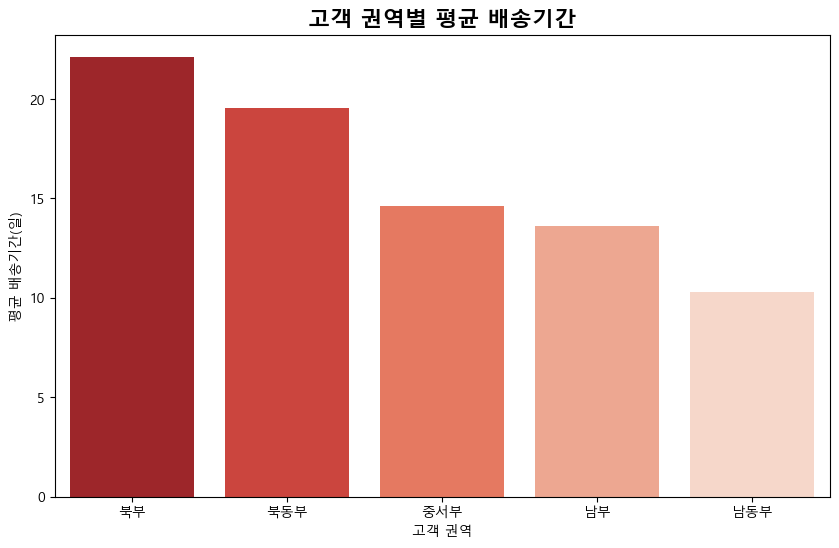

In [5]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_summary.reset_index(),
    x="customer_region",
    y="mean",
    palette="Reds_r"
)

plt.title("고객 권역별 평균 배송기간", fontsize=16, weight="bold")
plt.xlabel("고객 권역")
plt.ylabel("평균 배송기간(일)")

plt.show()

## 해석 예시

Kruskal-Wallis 검정의 p-value가 0.05보다 작다면 고객 권역별 배송기간에는 통계적으로 유의미한 차이가 있다고 판단한다.

평균 배송기간이 긴 권역은 물류 접근성이 낮거나 기존 배송망에서 병목이 발생하는 지역으로 해석할 수 있다.

허브 선정 관점에서는 주문 수요가 충분하면서 배송기간이 긴 권역을 우선 검토할 수 있다.

# 가설 2. 고객 권역별 배송 지연률은 차이가 있는가?

## 분석 목적

고객 권역별로 배송 지연 발생 비율이 다른지 확인한다.

평균 배송기간뿐 아니라 예정일을 넘긴 비율이 높은 지역은 고객 불만족 리스크가 큰 지역으로 볼 수 있다.

## 가설

- H0: 고객 권역과 배송 지연 여부는 독립이다.
- H1: 고객 권역과 배송 지연 여부는 독립이 아니다.

## 사용 검정

- 카이제곱 독립성 검정
- 효과크기: Cramer's V

In [6]:
region_late_table = pd.crosstab(
    order_df["customer_region"],
    order_df["is_late"]
)

display(region_late_table)

chi2, p, dof, expected = stats.chi2_contingency(region_late_table)

n = region_late_table.to_numpy().sum()
r, c = region_late_table.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)
print("Cramer's V:", cramers_v)

is_late,False,True
customer_region,,
남동부,60000,4808
남부,12571,957
북동부,7594,1255
북부,1591,168
중서부,5060,439


Chi-square statistic: 505.68518517439543
p-value: 3.948405461787258e-108
degrees of freedom: 4
Cramer's V: 0.07317373583556079


In [7]:
region_late_rate = order_df.groupby("customer_region")["is_late"].agg(
    order_count="count",
    late_rate="mean"
).sort_values("late_rate", ascending=False)

region_late_rate["late_rate_pct"] = region_late_rate["late_rate"] * 100

display(region_late_rate)

,order_count,late_rate,late_rate_pct
customer_region,,,
북동부,8849,0.141824,14.182393
북부,1759,0.095509,9.550881
중서부,5499,0.079833,7.983270
남동부,64808,0.074188,7.418837
남부,13528,0.070742,7.074216


C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\2624806066.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


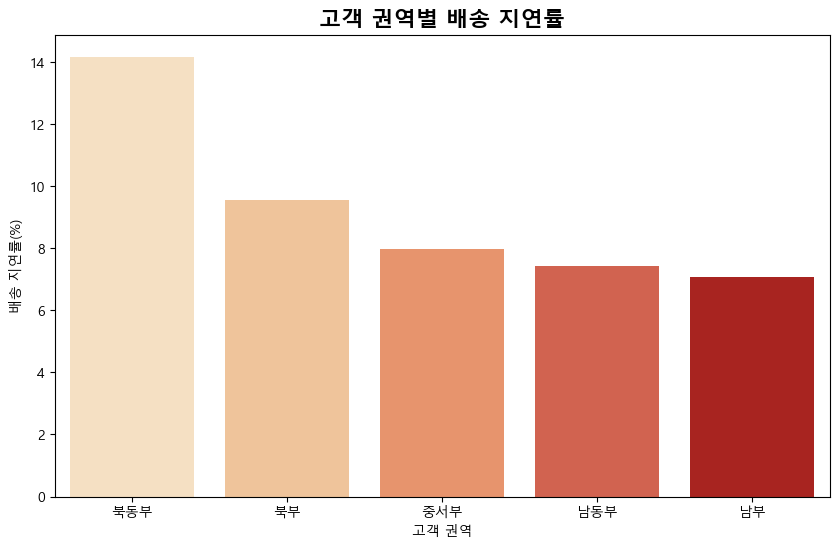

In [8]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_late_rate.reset_index(),
    x="customer_region",
    y="late_rate_pct",
    palette="OrRd"
)

plt.title("고객 권역별 배송 지연률", fontsize=16, weight="bold")
plt.xlabel("고객 권역")
plt.ylabel("배송 지연률(%)")

plt.show()

## 해석 예시

카이제곱 검정의 p-value가 0.05보다 작다면 고객 권역과 배송 지연 여부는 독립이 아니라고 판단한다.

즉, 특정 권역에서 배송 지연이 더 자주 발생한다는 의미이다.

허브 선정 관점에서는 지연률이 높은 권역을 기존 물류망의 취약 지역으로 보고, 허브 후보지 또는 배송망 개선 우선순위로 검토할 수 있다.

# 가설 3. 배송 route별 지연률은 차이가 있는가?

## 분석 목적

판매자 주에서 고객 주로 이어지는 배송 route별로 지연률 차이가 있는지 확인한다.

이는 물류 허브 선정에서 가장 직접적인 병목 경로 분석이다.

## 가설

- H0: 배송 route와 배송 지연 여부는 독립이다.
- H1: 배송 route와 배송 지연 여부는 독립이 아니다.

## 사용 검정

- 카이제곱 독립성 검정

단, 표본 수가 너무 적은 route는 검정 안정성이 낮으므로 최소 주문 수 기준을 설정한다.

In [9]:
# 최소 주문 수 100건 이상인 route만 사용
route_counts = order_df["delivery_route"].value_counts()
valid_routes = route_counts[route_counts >= 100].index

route_df = order_df[order_df["delivery_route"].isin(valid_routes)].copy()

route_late_table = pd.crosstab(
    route_df["delivery_route"],
    route_df["is_late"]
)

display(route_late_table.head())

chi2, p, dof, expected = stats.chi2_contingency(route_late_table)

n = route_late_table.to_numpy().sum()
r, c = route_late_table.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("분석 대상 route 수:", route_df["delivery_route"].nunique())
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)
print("Cramer's V:", cramers_v)

is_late,False,True
delivery_route,,
BA -> SP,129,7
DF -> MG,101,1
DF -> SP,292,9
GO -> SP,120,5
MA -> SP,86,30


분석 대상 route 수: 69
Chi-square statistic: 1938.3281477077378
p-value: 0.0
degrees of freedom: 68
Cramer's V: 0.1473420920185899


In [10]:
route_summary = route_df.groupby("delivery_route").agg(
    order_count=("order_id", "count"),
    late_rate=("is_late", "mean"),
    avg_delivery_days=("delivery_days_clean", "mean"),
    avg_review_score=("review_score_mean", "mean")
).sort_values("late_rate", ascending=False)

route_summary["late_rate_pct"] = route_summary["late_rate"] * 100

display(route_summary.head(20))

,order_count,late_rate,avg_delivery_days,avg_review_score,late_rate_pct
delivery_route,,,,,
MA -> SP,116,0.258621,16.025862,3.879310,25.862069
SP -> AL,251,0.254980,24.382470,3.741036,25.498008
SP -> MA,475,0.212632,21.553684,3.718947,21.263158
SP -> PI,322,0.183230,19.956522,3.959627,18.322981
SP -> SE,206,0.165049,20.956311,3.815534,16.504854
PR -> BA,140,0.164286,21.421429,3.821429,16.428571
SP -> RJ,7975,0.154483,15.827085,3.883490,15.448276
SP -> CE,948,0.154008,20.835443,3.965717,15.400844
SP -> MS,473,0.147992,15.583510,4.071882,14.799154


C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\2393456439.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


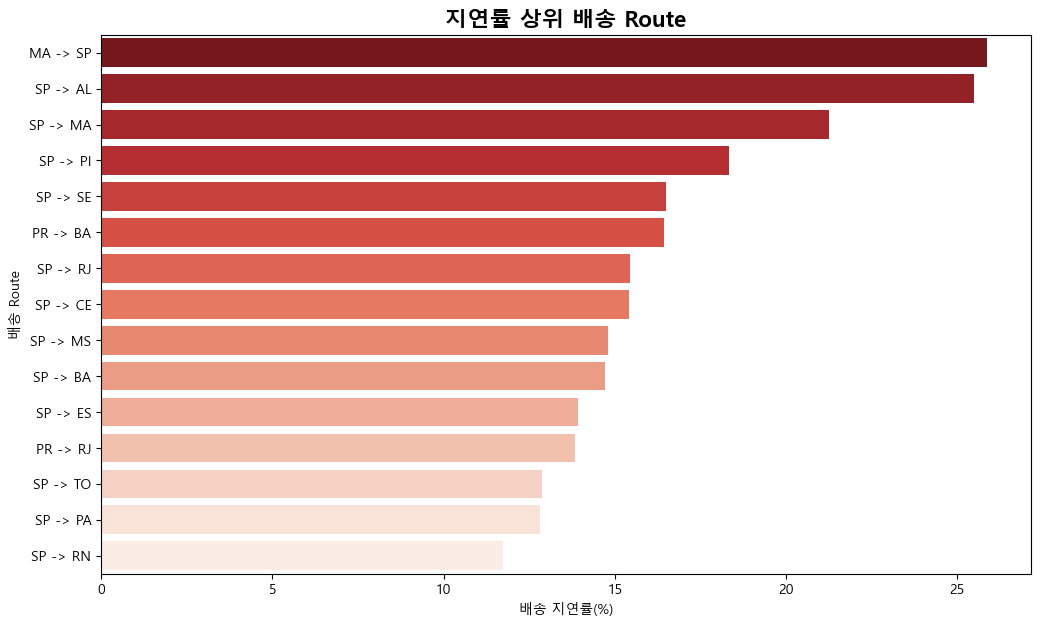

In [11]:
top_route_plot = route_summary.head(15).reset_index()

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_route_plot,
    y="delivery_route",
    x="late_rate_pct",
    palette="Reds_r"
)

plt.title("지연률 상위 배송 Route", fontsize=16, weight="bold")
plt.xlabel("배송 지연률(%)")
plt.ylabel("배송 Route")

plt.show()

## 해석 예시

카이제곱 검정의 p-value가 0.05보다 작다면 배송 route별 지연률에는 통계적으로 유의미한 차이가 있다고 판단한다.

지연률이 높고 주문 수가 충분한 route는 물류 병목 경로로 해석할 수 있다.

허브 선정 관점에서는 이러한 병목 route를 줄일 수 있는 위치가 허브 후보로 적합하다.

# 가설 4. 동일 주 배송은 타 주 배송보다 배송기간이 짧은가?

## 분석 목적

판매자와 고객이 같은 주에 위치한 경우 배송기간이 더 짧은지 확인한다.

동일 주 배송이 유의하게 빠르다면, 고객 수요지 근처에 허브를 배치해야 한다는 근거가 된다.

## 가설

- H0: 동일 주 배송과 타 주 배송의 배송기간 차이는 없다.
- H1: 동일 주 배송과 타 주 배송의 배송기간 차이는 있다.

## 사용 검정

- Welch's t-test
- Mann-Whitney U test

배송기간은 이상치가 있을 수 있으므로 Mann-Whitney U test를 우선적으로 해석한다.

In [12]:
same_state_delivery = order_df.loc[
    order_df["seller_customer_same_state"] == True,
    "delivery_days_clean"
].dropna()

diff_state_delivery = order_df.loc[
    order_df["seller_customer_same_state"] == False,
    "delivery_days_clean"
].dropna()

print("동일 주 배송 평균:", same_state_delivery.mean())
print("타 주 배송 평균:", diff_state_delivery.mean())
print("동일 주 배송 중앙값:", same_state_delivery.median())
print("타 주 배송 중앙값:", diff_state_delivery.median())

ttest_result = stats.ttest_ind(
    same_state_delivery,
    diff_state_delivery,
    equal_var=False
)

mw_result = stats.mannwhitneyu(
    same_state_delivery,
    diff_state_delivery,
    alternative="two-sided"
)

print("Welch's t-test:", ttest_result)
print("Mann-Whitney U:", mw_result)

동일 주 배송 평균: 7.511420498027904
타 주 배송 평균: 14.694967669384313
동일 주 배송 중앙값: 6.0
타 주 배송 중앙값: 12.0
Welch's t-test: TtestResult(statistic=np.float64(-134.85458933912972), pvalue=np.float64(0.0), df=np.float64(92918.56393658376))
Mann-Whitney U: MannwhitneyuResult(statistic=np.float64(417364045.0), pvalue=np.float64(0.0))


C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\3304371318.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


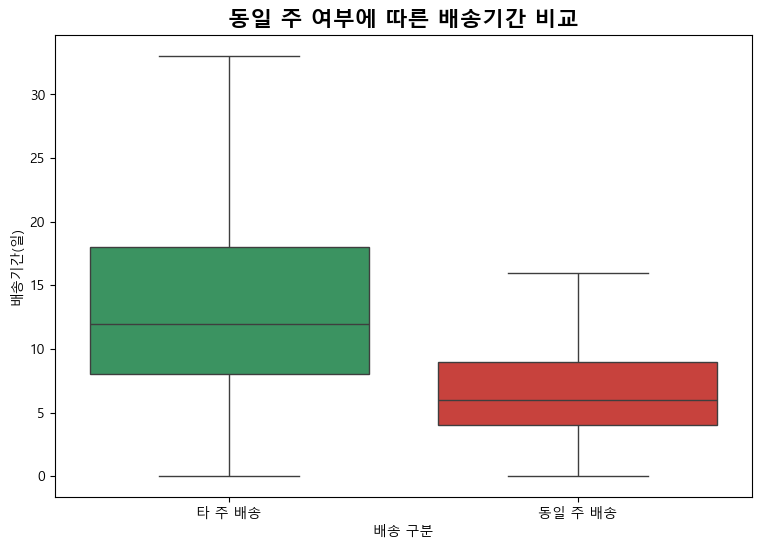

In [13]:
same_state_plot = order_df.copy()
same_state_plot["same_state_label"] = same_state_plot["seller_customer_same_state"].map({
    True: "동일 주 배송",
    False: "타 주 배송"
})

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=same_state_plot,
    x="same_state_label",
    y="delivery_days_clean",
    palette=["#2ca25f", "#de2d26"],
    showfliers=False
)

plt.title("동일 주 여부에 따른 배송기간 비교", fontsize=16, weight="bold")
plt.xlabel("배송 구분")
plt.ylabel("배송기간(일)")

plt.show()

## 해석 예시

Mann-Whitney U test의 p-value가 0.05보다 작다면 동일 주 배송과 타 주 배송의 배송기간 분포에는 유의미한 차이가 있다고 판단한다.

동일 주 배송의 평균 또는 중앙값 배송기간이 더 짧다면, 판매자와 고객의 지리적 근접성이 배송 효율을 높인다고 해석할 수 있다.

이는 주요 수요 지역 인근에 물류 허브를 배치하는 전략의 통계적 근거가 된다.

# 가설 5. 배송 지연은 고객 만족도 하락과 연결되는가?

## 분석 목적

배송 지연이 고객 리뷰점수 하락과 연결되는지 확인한다.

허브 선정 분석에서 중요한 것은 단순히 배송이 늦는 지역을 찾는 것뿐 아니라, 그 지연이 고객 만족도에 실제로 영향을 주는지 검증하는 것이다.

## 가설

- H0: 지연 배송과 비지연 배송의 리뷰점수 차이는 없다.
- H1: 지연 배송과 비지연 배송의 리뷰점수 차이는 있다.

## 사용 검정

- Welch's t-test
- Mann-Whitney U test

리뷰점수는 1~5점 순서형 변수이므로 Mann-Whitney U test를 우선적으로 해석한다.

In [14]:
late_review = order_df.loc[
    order_df["is_late"] == True,
    "review_score_mean"
].dropna()

not_late_review = order_df.loc[
    order_df["is_late"] == False,
    "review_score_mean"
].dropna()

print("지연 배송 리뷰점수 평균:", late_review.mean())
print("비지연 배송 리뷰점수 평균:", not_late_review.mean())
print("지연 배송 리뷰점수 중앙값:", late_review.median())
print("비지연 배송 리뷰점수 중앙값:", not_late_review.median())

ttest_result = stats.ttest_ind(
    late_review,
    not_late_review,
    equal_var=False
)

mw_result = stats.mannwhitneyu(
    late_review,
    not_late_review,
    alternative="two-sided"
)

print("Welch's t-test:", ttest_result)
print("Mann-Whitney U:", mw_result)

지연 배송 리뷰점수 평균: 2.5641798872426906
비지연 배송 리뷰점수 평균: 4.293766893967318
지연 배송 리뷰점수 중앙값: 2.0
비지연 배송 리뷰점수 중앙값: 5.0
Welch's t-test: TtestResult(statistic=np.float64(-89.2810083157793), pvalue=np.float64(0.0), df=np.float64(8278.753257135792))
Mann-Whitney U: MannwhitneyuResult(statistic=np.float64(147575026.5), pvalue=np.float64(0.0))


,delay_label,count,mean,median
0,비지연 배송,86816,4.293767,5.0
1,지연 배송,7627,2.564180,2.0


C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\2015601254.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


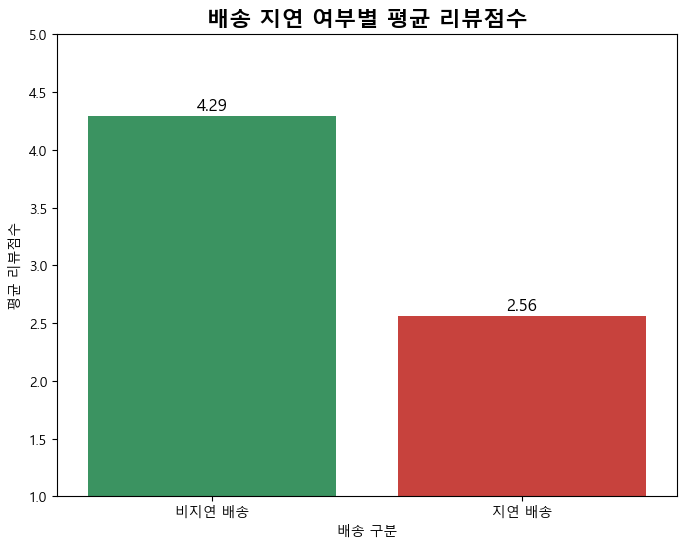

In [15]:
review_delay_plot = order_df.copy()
review_delay_plot["delay_label"] = review_delay_plot["is_late"].map({
    True: "지연 배송",
    False: "비지연 배송"
})

review_summary = review_delay_plot.groupby("delay_label")["review_score_mean"].agg(
    count="count",
    mean="mean",
    median="median"
).reset_index()

display(review_summary)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=review_summary,
    x="delay_label",
    y="mean",
    palette=["#2ca25f", "#de2d26"]
)

plt.title("배송 지연 여부별 평균 리뷰점수", fontsize=16, weight="bold")
plt.xlabel("배송 구분")
plt.ylabel("평균 리뷰점수")
plt.ylim(1, 5)

for i, row in review_summary.iterrows():
    plt.text(
        i,
        row["mean"] + 0.05,
        f'{row["mean"]:.2f}',
        ha="center",
        fontsize=12
    )

plt.show()

## 해석 예시

Mann-Whitney U test의 p-value가 0.05보다 작다면 지연 배송과 비지연 배송의 리뷰점수 분포에는 유의미한 차이가 있다고 판단한다.

지연 배송의 평균 리뷰점수가 비지연 배송보다 낮다면, 배송 지연은 고객 만족도 하락과 연결된다고 해석할 수 있다.

허브 선정 관점에서는 배송 지연률이 높은 지역 또는 route를 개선하는 것이 고객 만족도 개선으로 이어질 수 있다는 근거가 된다.

# 최종 정리

## 배송/물류 허브 선정에서의 통계적 근거

본 분석에서는 물류 허브 선정에 필요한 5가지 핵심 검정을 수행하였다.

| 검정 주제 | 사용 검정 | 허브 선정에서의 의미 |
|---|---|---|
| 고객 권역별 배송기간 차이 | Kruskal-Wallis | 배송이 구조적으로 오래 걸리는 권역 식별 |
| 고객 권역별 지연률 차이 | 카이제곱 검정 | 약속 배송 실패가 많은 권역 식별 |
| 배송 route별 지연률 차이 | 카이제곱 검정 | 병목 배송 경로 식별 |
| 동일 주 배송 vs 타 주 배송 | Mann-Whitney U | 수요지 인근 허브 필요성 검증 |
| 배송 지연과 리뷰점수 차이 | Mann-Whitney U | 물류 개선이 고객 만족도 개선과 연결됨을 검증 |

## 포트폴리오용 해석 문장 예시

통계검정 결과, 고객 권역과 배송 route에 따라 배송기간 및 지연률에는 유의미한 차이가 존재하는 것으로 나타났다.

또한 판매자와 고객이 같은 주에 위치한 경우 배송기간이 더 짧았으며, 배송 지연 주문은 비지연 주문보다 리뷰점수가 낮게 나타났다.

이는 물류 허브 선정 시 단순 주문량뿐 아니라 권역별 배송기간, 지연률, route 병목, 고객 만족도 영향을 함께 고려해야 함을 시사한다.

따라서 신규 허브 후보는 주문 수요가 충분하면서도 평균 배송기간과 지연률이 높은 권역 또는 병목 route를 완화할 수 있는 위치를 중심으로 검토하는 것이 적절하다.

---

# 물류 허브 및 카테고리 사전재고 전략을 위한 통계 검정

## 분석 목적

본 분석은 배송 지연을 줄이기 위한 물류 전략 수립을 목적으로 한다.

특히 다음 두 가지 전략을 검토한다.

1. 수요가 많은 카테고리의 상품을 주요 고객 지역 창고에 사전 배치하는 전략
2. 배송 지연률이 높은 병목 route 또는 권역에 추가 물류 허브를 구축하는 전략

이를 위해 다음 질문을 통계적으로 검증한다.

1. 고객 권역별로 수요가 집중되는 상품 카테고리가 다른가?
2. 특정 상품 카테고리는 배송 지연률이 더 높은가?
3. 특정 고객 권역-카테고리 조합에서 지연이 집중되는가?
4. 특정 배송 route에서 지연률과 배송기간이 유의하게 높은가?
5. 동일 주 배송은 타 주 배송보다 배송기간과 지연률이 개선되는가?
6. 배송 지연이 리뷰점수 하락과 연결되는가?

이 분석은 단순히 “어디에 주문이 많은가”가 아니라, “어디에서 어떤 상품이 자주 늦고, 그 지연이 고객 만족도에 영향을 주는가”를 기준으로 물류 허브와 사전재고 후보를 선정하기 위한 것이다.

In [16]:
# 기본 파생변수 생성

date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df["delivery_gap_days"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

df["delivery_gap_days"] = np.floor(df["delivery_gap_days"])
df["is_delay"] = df["delivery_gap_days"] > 0

df["review_score_int"] = df["review_score_mean"].round().astype("Int64")

df["product_volume_cm3"] = (
    df["product_length_cm"] *
    df["product_height_cm"] *
    df["product_width_cm"]
)

df["category"] = df["product_category_name_english"].fillna("unknown")

df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_total,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_date,purchase_year,purchase_month,purchase_weekday,purchase_hour,anomaly_carrier_before_approved,anomaly_customer_before_carrier,anomaly_missing_required_delivery_date,anomaly_flag,delivery_days_all,delivery_days_clean,is_late,is_delivered,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_state_kor,customer_region,customer_geo_lat,customer_geo_lng,customer_geo_city,customer_geo_state,seller_zip_code_prefix,seller_city,seller_state,seller_state_kor,seller_region,seller_geo_lat,seller_geo_lng,seller_geo_city,seller_geo_state,seller_state_geo_mismatch,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_value_total,payment_installments_max,payment_type_nunique,payment_types,review_score_mean,review_count,review_creation_min,review_answer_max,seller_customer_same_state,delivery_route,is_seller_geo_unreliable,delivery_gap_days,is_delay,review_score_int,product_volume_cm3,category
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,2017-09-13,2017,9,Wednesday,8,False,False,False,0,7,7,False,True,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,리우데자네이루주,남동부,-21.762775,-41.309633,campos dos goytacazes,RJ,27277,volta redonda,SP,상파울루주,남동부,-22.496953,-44.127492,volta redonda,RJ,True,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,72.19,2.0,1.0,credit_card,5.0,1.0,2017-09-21 00:00:00,2017-09-22 10:57:03,False,SP -> RJ,True,-9.0,False,5,3528.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,2017-04-26,2017,4,Wednesday,10,False,False,False,0,16,16,False,True,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,상파울루주,남동부,-20.220527,-50.903424,santa fe do sul,SP,3471,sao paulo,SP,상파울루주,남동부,-23.565096,-46.518565,sao paulo,SP,False,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,259.83,3.0,1.0,credit_card,4.0,1.0,2017-05-13 00:00:00,2017-05-15 11:34:13,True,SP -> SP,False,-3.0,False,4,60000.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,2018-01-14,2018,1,Sunday,14,False,False,False,0,7,7,False,True,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,미나스제라이스주,남동부,-19.870305,-44.593326,para de minas,MG,37564,borda da mata,MG,미나스제라이스주,남동부,-22.262584,-46.171124,borda da mata,MG,False,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,216.87,5.0,1.0,credit_card,5.0,1.0,2018-01-23 00:00:00,2018-01-23 16:06:31,True,MG -> MG,False,-14.0,False,5,14157.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,2018-08-08,2018,8,Wednesday,10,False,False,False,0,6,6,False,True,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,상파울루주,남동부,-23.089925,-46.611654,atibaia,SP,14403,franca,SP,상파울루주,남동부,-20.553624,-47.387359,franca,SP,False,perfumaria,42.0,48

## 분석 단위 설정

본 분석에서는 목적에 따라 두 가지 분석 단위를 사용한다.

| 분석 목적 | 분석 단위 | 이유 |
|---|---|---|
| 배송기간, 지연률, 리뷰점수 분석 | 주문 단위 | 리뷰와 배송일은 주문 단위 변수이므로 중복 방지 필요 |
| 카테고리 수요 및 사전재고 분석 | 주문-카테고리 단위 | 한 주문에 여러 카테고리가 포함될 수 있으므로 카테고리별 수요 확인 필요 |

카테고리 분석에서는 동일 주문 내 같은 카테고리가 여러 번 반복될 수 있으므로 `order_id + category` 기준으로 중복을 제거한 주문-카테고리 단위 테이블을 사용한다.

In [17]:
# 주문 단위 테이블

order_df = df.groupby("order_id", as_index=False).agg(
    delivery_days_clean=("delivery_days_clean", "first"),
    delivery_gap_days=("delivery_gap_days", "first"),
    is_delay=("is_delay", "first"),
    is_late=("is_late", "first"),
    review_score_mean=("review_score_mean", "first"),
    review_score_int=("review_score_int", "first"),
    
    customer_region=("customer_region", "first"),
    customer_state=("customer_state", "first"),
    seller_region=("seller_region", "first"),
    seller_state=("seller_state", "first"),
    seller_customer_same_state=("seller_customer_same_state", "first"),
    delivery_route=("delivery_route", "first"),
    
    price_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
    item_count=("order_item_id", "count")
)

order_df = order_df.dropna(subset=[
    "delivery_days_clean",
    "delivery_gap_days",
    "is_delay",
    "review_score_mean",
    "customer_region",
    "delivery_route"
]).copy()

order_df["is_one_star"] = order_df["review_score_int"] == 1
order_df["is_five_star"] = order_df["review_score_int"] == 5

order_df.shape

(94443, 18)

In [18]:
# 주문-카테고리 단위 테이블

order_category_df = df.drop_duplicates(
    subset=["order_id", "category"]
).copy()

order_category_df = order_category_df.dropna(subset=[
    "category",
    "customer_region",
    "delivery_days_clean",
    "delivery_gap_days",
    "review_score_mean"
]).copy()

order_category_df["is_one_star"] = order_category_df["review_score_int"] == 1
order_category_df["is_five_star"] = order_category_df["review_score_int"] == 5

order_category_df.shape

(95205, 75)

# 가설 1. 고객 권역별 수요 카테고리 분포는 다른가?

## 분석 목적

사전재고 전략을 세우려면 먼저 고객 권역별로 어떤 카테고리 수요가 많은지 확인해야 한다.

만약 권역별 카테고리 수요 분포가 다르다면, 모든 창고에 같은 상품을 배치하는 것보다 권역별로 다른 카테고리를 사전 배치하는 전략이 더 적절하다.

## 가설

- H0: 고객 권역과 상품 카테고리 수요 분포는 독립이다.
- H1: 고객 권역과 상품 카테고리 수요 분포는 독립이 아니다.

## 사용 검정

- 카이제곱 독립성 검정
- 효과크기: Cramer's V

In [19]:
# 주문 수 기준 상위 15개 카테고리만 사용
top_categories = (
    order_category_df["category"]
    .value_counts()
    .head(15)
    .index
)

cat_region_df = order_category_df[
    order_category_df["category"].isin(top_categories)
].copy()

cat_region_table = pd.crosstab(
    cat_region_df["customer_region"],
    cat_region_df["category"]
)

display(cat_region_table)

chi2, p, dof, expected = stats.chi2_contingency(cat_region_table)

n = cat_region_table.to_numpy().sum()
r, c = cat_region_table.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)
print("Cramer's V:", cramers_v)

category,auto,baby,bed_bath_table,computers_accessories,cool_stuff,electronics,furniture_decor,garden_tools,health_beauty,housewares,perfumery,sports_leisure,telephony,toys,watches_gifts
customer_region,,,,,,,,,,,,,,,
남동부,2468,1842,6852,4369,2221,1623,4235,2293,5667,4118,2131,5034,2391,2594,3531
남부,526,429,1169,958,593,422,1084,540,1016,827,381,1128,621,498,635
북동부,411,239,487,609,369,250,476,329,1028,314,269,647,604,330,704
북부,81,67,72,139,80,51,89,50,185,56,56,141,130,64,127
중서부,244,173,456,335,226,122,297,169,555,285,194,450,273,233,358


Chi-square statistic: 1126.399436975246
p-value: 4.546404454219617e-199
degrees of freedom: 56
Cramer's V: 0.06126715117337114


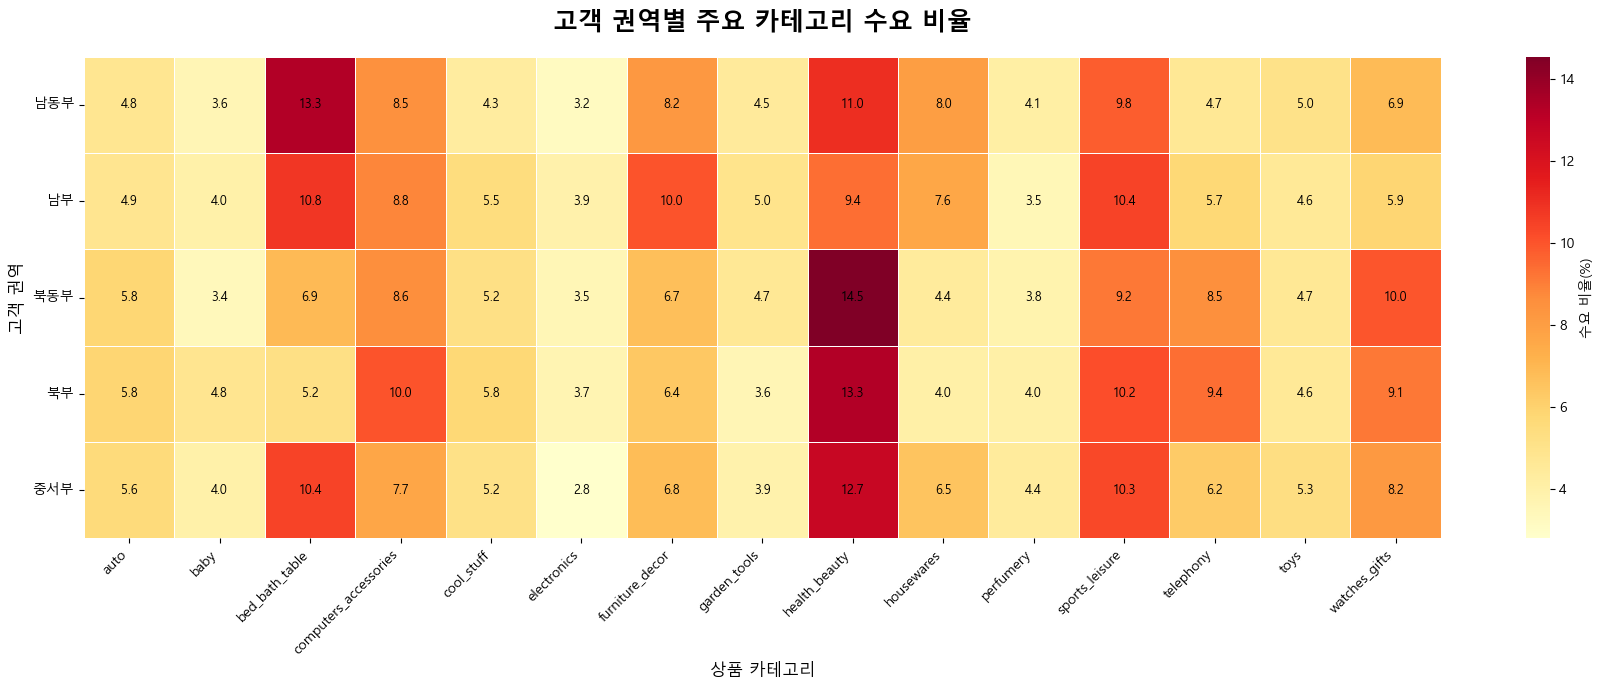

In [41]:
# 고객 권역별 주요 카테고리 수요 비율 히트맵 개선 버전

cat_region_rate = cat_region_table.div(
    cat_region_table.sum(axis=1),
    axis=0
) * 100

plt.figure(figsize=(18, 7))

ax = sns.heatmap(
    cat_region_rate,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "수요 비율(%)"},
    annot_kws={
        "fontsize": 9,
        "color": "black"
    }
)

plt.title("고객 권역별 주요 카테고리 수요 비율", fontsize=18, weight="bold", pad=20)
plt.xlabel("상품 카테고리", fontsize=12)
plt.ylabel("고객 권역", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 해석 예시

p-value가 0.05보다 작다면 고객 권역별 카테고리 수요 분포는 통계적으로 다르다고 해석한다.

이는 권역별로 사전재고를 배치할 카테고리를 다르게 선정해야 한다는 근거가 된다.

예를 들어 특정 권역에서 `bed_bath_table`, `health_beauty`, `computers_accessories` 등의 수요 비중이 높다면, 해당 권역 창고에 해당 카테고리를 우선 배치하는 전략을 검토할 수 있다.

# 가설 2. 상품 카테고리별 배송 지연률은 차이가 있는가?

## 분석 목적

수요가 많은 카테고리라도 배송 지연이 거의 없다면 사전재고 우선순위는 낮을 수 있다.

반대로 수요가 많고 지연률도 높은 카테고리는 주요 지역 창고에 미리 보관할 후보가 된다.

## 가설

- H0: 상품 카테고리와 배송 지연 여부는 독립이다.
- H1: 상품 카테고리와 배송 지연 여부는 독립이 아니다.

## 사용 검정

- 카이제곱 독립성 검정
- 효과크기: Cramer's V

In [21]:
cat_delay_df = order_category_df[
    order_category_df["category"].isin(top_categories)
].copy()

cat_delay_table = pd.crosstab(
    cat_delay_df["category"],
    cat_delay_df["is_delay"]
)

display(cat_delay_table)

chi2, p, dof, expected = stats.chi2_contingency(cat_delay_table)

n = cat_delay_table.to_numpy().sum()
r, c = cat_delay_table.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)
print("Cramer's V:", cramers_v)

is_delay,False,True
category,,
auto,3458,272
baby,2531,219
bed_bath_table,8370,666
computers_accessories,6004,406
cool_stuff,3286,203
electronics,2278,190
furniture_decor,5743,438
garden_tools,3161,220
health_beauty,7821,630


Chi-square statistic: 54.22731865775646
p-value: 1.1745977701211642e-06
degrees of freedom: 14
Cramer's V: 0.02688564967774558


In [22]:
cat_delay_summary = cat_delay_df.groupby("category").agg(
    order_count=("order_id", "nunique"),
    delay_rate=("is_delay", "mean"),
    avg_delivery_days=("delivery_days_clean", "mean"),
    avg_review_score=("review_score_mean", "mean")
).sort_values("delay_rate", ascending=False)

cat_delay_summary["delay_rate_pct"] = cat_delay_summary["delay_rate"] * 100

display(cat_delay_summary)

,order_count,delay_rate,avg_delivery_days,avg_review_score,delay_rate_pct
category,,,,,
baby,2750,0.079636,12.176727,4.098000,7.963636
electronics,2468,0.076985,12.489060,4.128849,7.698541
health_beauty,8451,0.074547,11.638031,4.225279,7.454739
bed_bath_table,9036,0.073705,12.544157,3.998174,7.370518
watches_gifts,5355,0.073389,12.345658,4.119888,7.338936
auto,3730,0.072922,11.871314,4.138874,7.292225
telephony,4019,0.071162,12.513809,4.053994,7.116198
furniture_decor,6181,0.070862,12.591814,4.055654,7.086232
sports_leisure,7400,0.065676,11.800946,4.223716,6.567568


C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\203252578.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


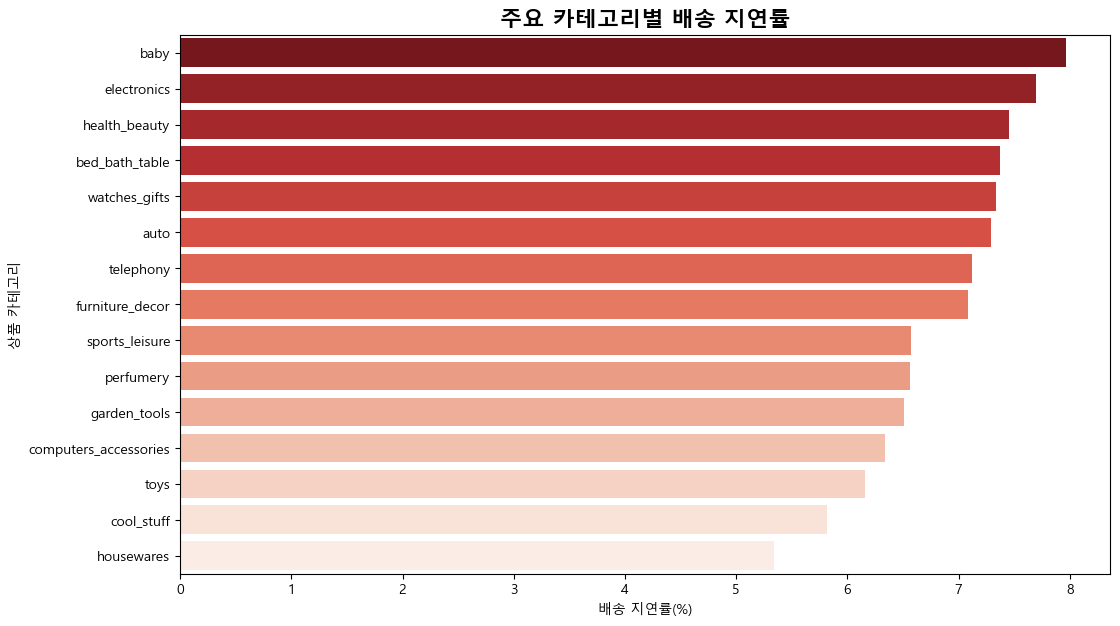

In [23]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=cat_delay_summary.reset_index(),
    y="category",
    x="delay_rate_pct",
    palette="Reds_r"
)

plt.title("주요 카테고리별 배송 지연률", fontsize=16, weight="bold")
plt.xlabel("배송 지연률(%)")
plt.ylabel("상품 카테고리")

plt.show()

## 해석 예시

p-value가 0.05보다 작다면 상품 카테고리별 배송 지연률에는 통계적으로 유의미한 차이가 있다고 판단한다.

수요량이 많고 지연률이 높은 카테고리는 주요 지역 창고에 사전 배치할 우선 후보가 된다.

단순히 많이 팔리는 상품이 아니라, 많이 팔리면서 자주 늦는 상품을 우선적으로 보는 것이 중요하다.

# 가설 3. 고객 권역-카테고리 조합별 배송 지연률은 차이가 있는가?

## 분석 목적

사전재고 전략은 단순히 전국 단위 카테고리 수요가 아니라, 특정 권역에서 특정 카테고리가 자주 늦는지를 확인해야 한다.

예를 들어 북동부 권역에서 특정 카테고리 수요가 많고 지연률도 높다면, 해당 권역 인근 창고에 그 카테고리를 보관하는 전략이 타당할 수 있다.

## 가설

- H0: 고객 권역-카테고리 조합과 배송 지연 여부는 독립이다.
- H1: 고객 권역-카테고리 조합과 배송 지연 여부는 독립이 아니다.

## 사용 검정

- 카이제곱 독립성 검정

In [24]:
region_cat_df = order_category_df[
    order_category_df["category"].isin(top_categories)
].copy()

region_cat_df["region_category"] = (
    region_cat_df["customer_region"].astype(str) +
    " | " +
    region_cat_df["category"].astype(str)
)

# 최소 주문 수 100건 이상 조합만 사용
combo_counts = region_cat_df["region_category"].value_counts()
valid_combos = combo_counts[combo_counts >= 100].index

region_cat_valid = region_cat_df[
    region_cat_df["region_category"].isin(valid_combos)
].copy()

region_cat_table = pd.crosstab(
    region_cat_valid["region_category"],
    region_cat_valid["is_delay"]
)

display(region_cat_table.head())

chi2, p, dof, expected = stats.chi2_contingency(region_cat_table)

print("분석 대상 권역-카테고리 조합 수:", region_cat_valid["region_category"].nunique())
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)

is_delay,False,True
region_category,,
남동부 | auto,2310,158
남동부 | baby,1697,145
남동부 | bed_bath_table,6384,468
남동부 | computers_accessories,4108,261
남동부 | cool_stuff,2095,126


분석 대상 권역-카테고리 조합 수: 65
Chi-square statistic: 598.0281203235435
p-value: 1.0437824480837328e-87
degrees of freedom: 64


In [25]:
region_cat_summary = region_cat_valid.groupby(
    ["customer_region", "category"]
).agg(
    order_count=("order_id", "nunique"),
    delay_rate=("is_delay", "mean"),
    avg_delivery_days=("delivery_days_clean", "mean"),
    avg_review_score=("review_score_mean", "mean")
).reset_index()

region_cat_summary["delay_rate_pct"] = region_cat_summary["delay_rate"] * 100

# 사전재고 후보: 주문 수와 지연률을 함께 고려
region_cat_summary["stock_priority_score"] = (
    region_cat_summary["order_count"].rank(pct=True) * 0.5 +
    region_cat_summary["delay_rate"].rank(pct=True) * 0.3 +
    region_cat_summary["avg_delivery_days"].rank(pct=True) * 0.2
)

region_cat_summary = region_cat_summary.sort_values(
    "stock_priority_score",
    ascending=False
)

display(region_cat_summary.head(20))

,customer_region,category,order_count,delay_rate,avg_delivery_days,avg_review_score,delay_rate_pct,stock_priority_score
38,북동부,health_beauty,1028,0.157588,19.575875,3.984436,15.758755,0.823077
44,북동부,watches_gifts,704,0.123580,19.420455,4.000000,12.357955,0.749231
42,북동부,telephony,604,0.137417,19.514901,3.859272,13.741722,0.732308
41,북동부,sports_leisure,647,0.115920,18.769706,4.030139,11.591963,0.730769
36,북동부,furniture_decor,476,0.144958,20.876050,3.815126,14.495798,0.716923
2,남동부,bed_bath_table,6852,0.068301,11.243870,4.025832,6.830123,0.710769
17,남부,bed_bath_table,1169,0.073567,14.813516,3.969204,7.356715,0.704615
32,북동부,bed_bath_table,487,0.127310,20.638604,3.815195,12.731006,0.693846
30,북동부,auto,411,0.160584,20.209246,3.817518,16.058394,0.678462
33,북동부,computers_accessories,609,0.098522,18.395731,4.077176,9.852217,0.663077


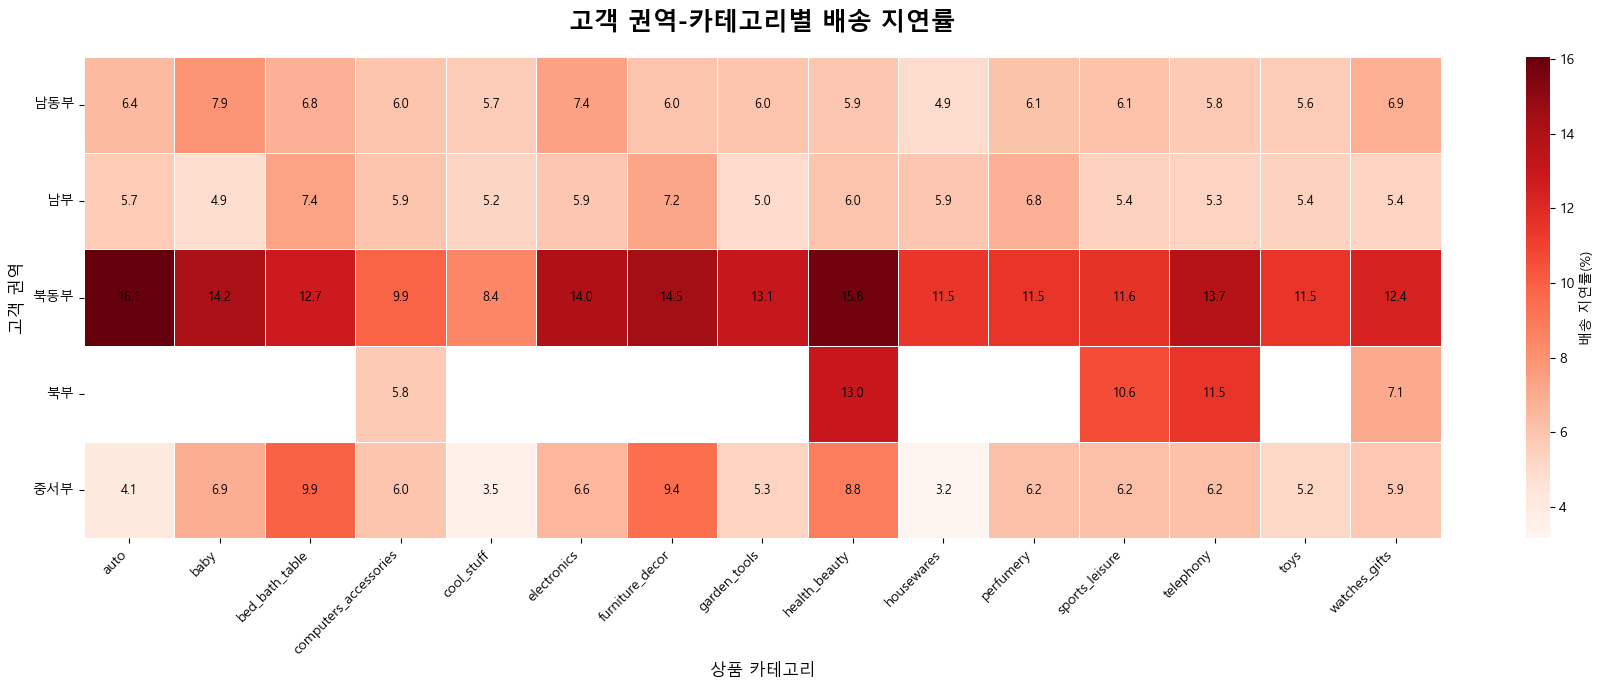

In [42]:
pivot_delay = region_cat_summary.pivot_table(
    index="customer_region",
    columns="category",
    values="delay_rate_pct"
)

plt.figure(figsize=(18, 7))

ax = sns.heatmap(
    pivot_delay,
    cmap="Reds",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "배송 지연률(%)"},
    annot_kws={
        "fontsize": 9,
        "color": "black"
    }
)

plt.title("고객 권역-카테고리별 배송 지연률", fontsize=18, weight="bold", pad=20)
plt.xlabel("상품 카테고리", fontsize=12)
plt.ylabel("고객 권역", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 해석 예시

p-value가 0.05보다 작다면 고객 권역-카테고리 조합에 따라 배송 지연률이 다르다고 판단한다.

`stock_priority_score`가 높은 조합은 주문 수요가 많고, 지연률이 높으며, 평균 배송기간도 긴 조합이다.

따라서 해당 조합은 주요 지역 창고에 사전재고를 배치할 우선 후보로 볼 수 있다.

# 가설 4. 상품 카테고리별 배송기간은 차이가 있는가?

## 분석 목적

카테고리별로 배송 난이도가 다른지 확인한다.

부피가 크거나 무거운 상품, 또는 특정 공급망에 의존하는 카테고리는 평균 배송기간이 길 수 있다.

## 가설

- H0: 상품 카테고리별 배송기간 분포는 같다.
- H1: 상품 카테고리별 배송기간 분포는 적어도 하나의 카테고리에서 다르다.

## 사용 검정

- ANOVA
- Kruskal-Wallis 검정

배송기간에는 이상치가 있으므로 Kruskal-Wallis 검정을 우선 해석한다.

In [27]:
cat_delivery_df = order_category_df[
    order_category_df["category"].isin(top_categories)
].dropna(subset=["delivery_days_clean"])

cat_delivery_summary = cat_delivery_df.groupby("category")["delivery_days_clean"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean", ascending=False)

display(cat_delivery_summary)

groups = [
    group["delivery_days_clean"].values
    for _, group in cat_delivery_df.groupby("category")
]

anova_result = stats.f_oneway(*groups)
kruskal_result = stats.kruskal(*groups)

print("ANOVA:", anova_result)
print("Kruskal-Wallis:", kruskal_result)

,count,mean,median,std
category,,,,
garden_tools,3381,13.162674,11.0,9.072139
computers_accessories,6410,12.753042,11.0,9.234637
furniture_decor,6181,12.591814,10.0,9.848243
bed_bath_table,9036,12.544157,10.0,9.277636
telephony,4019,12.513809,10.0,9.251478
electronics,2468,12.489060,11.0,9.080434
watches_gifts,5355,12.345658,10.0,9.603662
baby,2750,12.176727,10.0,9.993707
cool_stuff,3489,11.901118,10.0,9.611175


ANOVA: F_onewayResult(statistic=np.float64(23.784505498011466), pvalue=np.float64(2.1341851922137106e-62))
Kruskal-Wallis: KruskalResult(statistic=np.float64(741.3930245717812), pvalue=np.float64(3.7359079225991915e-149))


C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\878685766.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


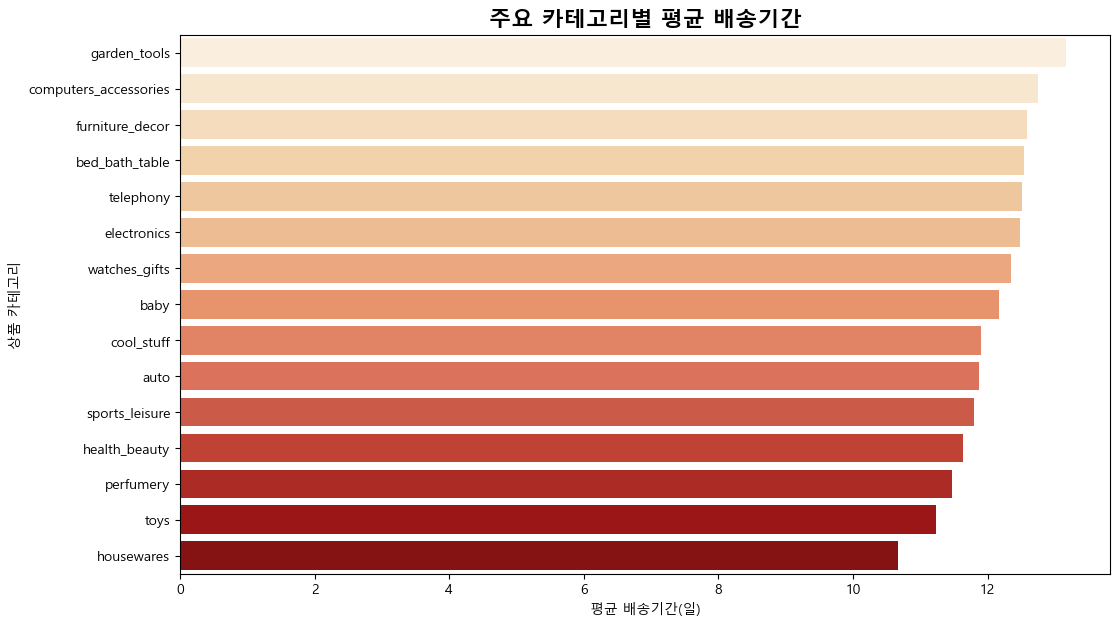

In [28]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=cat_delivery_summary.reset_index(),
    y="category",
    x="mean",
    palette="OrRd"
)

plt.title("주요 카테고리별 평균 배송기간", fontsize=16, weight="bold")
plt.xlabel("평균 배송기간(일)")
plt.ylabel("상품 카테고리")

plt.show()

## 해석 예시

Kruskal-Wallis 검정의 p-value가 0.05보다 작다면 상품 카테고리별 배송기간에는 유의미한 차이가 있다고 판단한다.

평균 배송기간이 길면서 수요량도 많은 카테고리는 사전재고 또는 별도 물류 처리 전략이 필요한 후보로 볼 수 있다.

# 가설 5. 상품 무게와 부피가 클수록 배송기간이 길어지는가?

## 분석 목적

창고 사전재고 전략에서는 어떤 상품을 미리 저장할지 판단해야 한다.

상품 무게나 부피가 배송 지연 또는 배송기간 증가와 관련 있다면, 대형/중량 상품은 별도 물류 전략이 필요할 수 있다.

## 가설

- H0: 상품 무게/부피와 배송기간 간 상관관계는 없다.
- H1: 상품 무게/부피와 배송기간 간 상관관계가 있다.

## 사용 검정

- Spearman 상관분석

In [29]:
physical_df = df[[
    "product_weight_g",
    "product_volume_cm3",
    "delivery_days_clean",
    "delivery_gap_days",
    "review_score_mean"
]].replace([np.inf, -np.inf], np.nan).dropna()

weight_corr = stats.spearmanr(
    physical_df["product_weight_g"],
    physical_df["delivery_days_clean"]
)

volume_corr = stats.spearmanr(
    physical_df["product_volume_cm3"],
    physical_df["delivery_days_clean"]
)

print("무게 vs 배송기간 Spearman:", weight_corr)
print("부피 vs 배송기간 Spearman:", volume_corr)

무게 vs 배송기간 Spearman: SignificanceResult(statistic=np.float64(0.09991829996930655), pvalue=np.float64(4.317777308582168e-237))
부피 vs 배송기간 Spearman: SignificanceResult(statistic=np.float64(0.07994921384418184), pvalue=np.float64(2.875806565893057e-152))


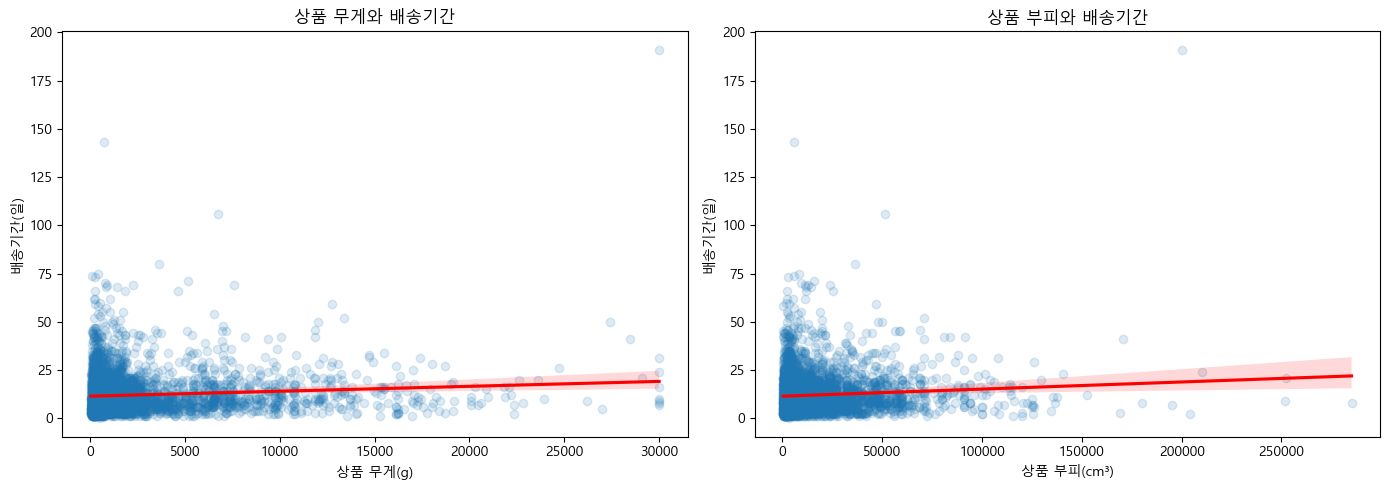

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_df = physical_df.sample(min(len(physical_df), 5000), random_state=42)

sns.regplot(
    data=sample_df,
    x="product_weight_g",
    y="delivery_days_clean",
    scatter_kws={"alpha": 0.15},
    line_kws={"color": "red"},
    ax=axes[0]
)

axes[0].set_title("상품 무게와 배송기간")
axes[0].set_xlabel("상품 무게(g)")
axes[0].set_ylabel("배송기간(일)")

sns.regplot(
    data=sample_df,
    x="product_volume_cm3",
    y="delivery_days_clean",
    scatter_kws={"alpha": 0.15},
    line_kws={"color": "red"},
    ax=axes[1]
)

axes[1].set_title("상품 부피와 배송기간")
axes[1].set_xlabel("상품 부피(cm³)")
axes[1].set_ylabel("배송기간(일)")

plt.tight_layout()
plt.show()

## 해석 예시

Spearman 상관계수가 양수이고 p-value가 0.05보다 작다면 상품 무게 또는 부피가 클수록 배송기간이 길어지는 경향이 있다고 해석할 수 있다.

다만 상관계수가 작다면 상품 크기는 배송기간에 영향을 주는 보조 요인으로 해석하는 것이 적절하다.

이 결과는 사전재고 후보를 선정할 때 단순 수요량뿐 아니라 보관 난이도와 배송 난이도를 함께 고려해야 함을 시사한다.

# 가설 6. 배송 route별 지연률은 차이가 있는가?

## 분석 목적

주요 물류 허브를 병목 구간에 추가하기 위해서는 어떤 route에서 지연이 집중되는지 확인해야 한다.

## 가설

- H0: 배송 route와 배송 지연 여부는 독립이다.
- H1: 배송 route와 배송 지연 여부는 독립이 아니다.

## 사용 검정

- 카이제곱 독립성 검정

In [31]:
route_counts = order_df["delivery_route"].value_counts()
valid_routes = route_counts[route_counts >= 100].index

route_df = order_df[
    order_df["delivery_route"].isin(valid_routes)
].copy()

route_late_table = pd.crosstab(
    route_df["delivery_route"],
    route_df["is_delay"]
)

chi2, p, dof, expected = stats.chi2_contingency(route_late_table)

n = route_late_table.to_numpy().sum()
r, c = route_late_table.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("분석 대상 route 수:", route_df["delivery_route"].nunique())
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)
print("Cramer's V:", cramers_v)

분석 대상 route 수: 69
Chi-square statistic: 2099.0802219450775
p-value: 0.0
degrees of freedom: 68
Cramer's V: 0.15333019885418064


In [32]:
route_summary = route_df.groupby("delivery_route").agg(
    order_count=("order_id", "count"),
    delay_rate=("is_delay", "mean"),
    avg_delivery_days=("delivery_days_clean", "mean"),
    avg_delay_days=("delivery_gap_days", "mean"),
    avg_review_score=("review_score_mean", "mean")
).sort_values("delay_rate", ascending=False)

route_summary["delay_rate_pct"] = route_summary["delay_rate"] * 100

# 병목 route 점수
route_summary["bottleneck_score"] = (
    route_summary["order_count"].rank(pct=True) * 0.4 +
    route_summary["delay_rate"].rank(pct=True) * 0.35 +
    route_summary["avg_delivery_days"].rank(pct=True) * 0.25
)

route_summary = route_summary.sort_values("bottleneck_score", ascending=False)

display(route_summary.head(20))

,order_count,delay_rate,avg_delivery_days,avg_delay_days,avg_review_score,delay_rate_pct,bottleneck_score
delivery_route,,,,,,,
SP -> RJ,7975,0.140690,15.827085,-10.793103,3.883490,14.068966,0.880435
SP -> BA,2263,0.126823,19.323023,-10.798498,3.866107,12.682280,0.880435
SP -> CE,948,0.138186,20.835443,-10.892405,3.965717,13.818565,0.847826
SP -> MA,475,0.191579,21.553684,-9.309474,3.718947,19.157895,0.826087
SP -> PA,663,0.116139,22.788839,-14.085973,3.868778,11.613876,0.807971
SP -> ES,1430,0.120979,15.284615,-9.614685,4.044755,12.097902,0.786232
PR -> RJ,940,0.119149,16.841489,-13.077660,3.890426,11.914894,0.781884
SP -> PE,1105,0.097738,18.416290,-13.660633,4.039819,9.773756,0.781159
SP -> SC,2271,0.095993,15.383531,-10.966535,4.029943,9.599295,0.766667


C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\3052589255.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


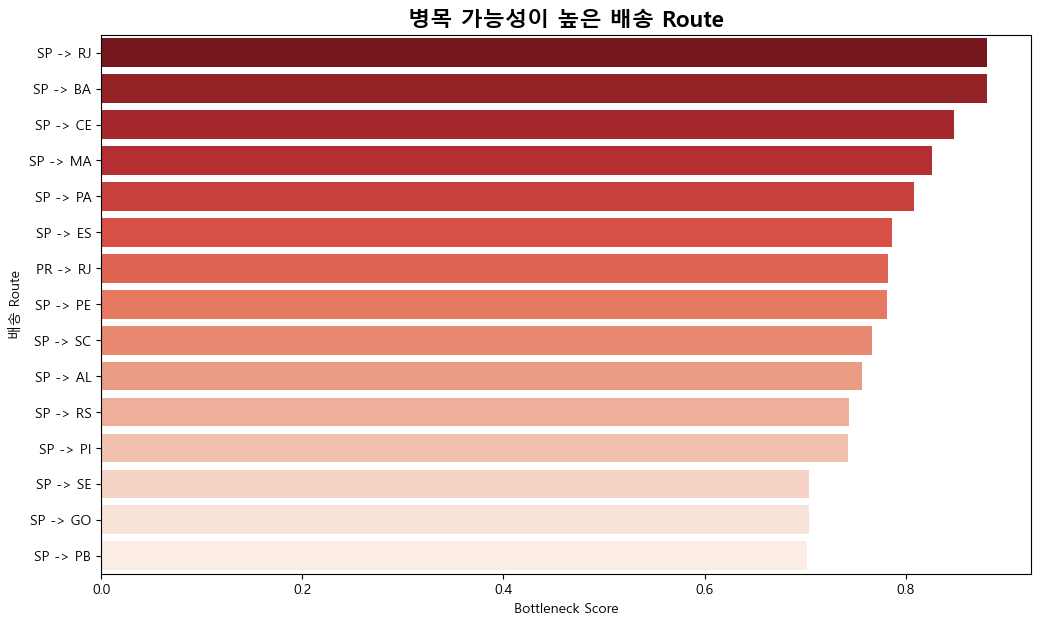

In [33]:
top_bottleneck = route_summary.head(15).reset_index()

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_bottleneck,
    y="delivery_route",
    x="bottleneck_score",
    palette="Reds_r"
)

plt.title("병목 가능성이 높은 배송 Route", fontsize=16, weight="bold")
plt.xlabel("Bottleneck Score")
plt.ylabel("배송 Route")

plt.show()

## 해석 예시

p-value가 0.05보다 작다면 배송 route별 지연률에는 통계적으로 유의미한 차이가 있다고 판단한다.

`bottleneck_score`가 높은 route는 주문 수가 많고, 지연률이 높으며, 평균 배송기간도 긴 경로이다.

따라서 해당 route를 완화할 수 있는 위치에 물류 허브를 추가하는 전략을 검토할 수 있다.

# 가설 7. 동일 주 배송은 타 주 배송보다 배송기간과 지연률이 개선되는가?

## 분석 목적

허브가 고객 수요지 가까이에 있을수록 배송 성과가 개선되는지 확인한다.

판매자와 고객이 같은 주에 있는 주문이 더 빠르고 덜 지연된다면, 주요 고객 지역 인근 허브 구축의 근거가 된다.

## 가설

- H0-1: 동일 주 배송과 타 주 배송의 배송기간 차이는 없다.
- H1-1: 동일 주 배송과 타 주 배송의 배송기간 차이는 있다.
- H0-2: 동일 주 배송 여부와 배송 지연 여부는 독립이다.
- H1-2: 동일 주 배송 여부와 배송 지연 여부는 독립이 아니다.

## 사용 검정

- Mann-Whitney U test
- 카이제곱 독립성 검정

In [34]:
same_state_delivery = order_df.loc[
    order_df["seller_customer_same_state"] == True,
    "delivery_days_clean"
].dropna()

diff_state_delivery = order_df.loc[
    order_df["seller_customer_same_state"] == False,
    "delivery_days_clean"
].dropna()

mw_result = stats.mannwhitneyu(
    same_state_delivery,
    diff_state_delivery,
    alternative="two-sided"
)

print("동일 주 배송 평균:", same_state_delivery.mean())
print("타 주 배송 평균:", diff_state_delivery.mean())
print("Mann-Whitney U:", mw_result)

동일 주 배송 평균: 7.511420498027904
타 주 배송 평균: 14.694967669384313
Mann-Whitney U: MannwhitneyuResult(statistic=np.float64(417364045.0), pvalue=np.float64(0.0))


In [35]:
same_state_late_table = pd.crosstab(
    order_df["seller_customer_same_state"],
    order_df["is_delay"]
)

display(same_state_late_table)

chi2, p, dof, expected = stats.chi2_contingency(same_state_late_table)

n = same_state_late_table.to_numpy().sum()
phi = np.sqrt(chi2 / n)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Phi coefficient:", phi)

is_delay,False,True
seller_customer_same_state,,
False,55646,4823
True,32441,1533


Chi-square statistic: 415.20338267333193
p-value: 2.7008525994654328e-92
Phi coefficient: 0.06630488932782205


In [36]:
same_state_summary = order_df.groupby("seller_customer_same_state").agg(
    order_count=("order_id", "count"),
    avg_delivery_days=("delivery_days_clean", "mean"),
    delay_rate=("is_delay", "mean"),
    avg_review_score=("review_score_mean", "mean")
).reset_index()

same_state_summary["same_state_label"] = same_state_summary["seller_customer_same_state"].map({
    True: "동일 주 배송",
    False: "타 주 배송"
})

same_state_summary["delay_rate_pct"] = same_state_summary["delay_rate"] * 100

display(same_state_summary)

,seller_customer_same_state,order_count,avg_delivery_days,delay_rate,avg_review_score,same_state_label,delay_rate_pct
0,False,60469,14.694968,0.079760,4.093715,타 주 배송,7.975988
1,True,33974,7.511420,0.045123,4.261548,동일 주 배송,4.512274


C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\422540673.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\422540673.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


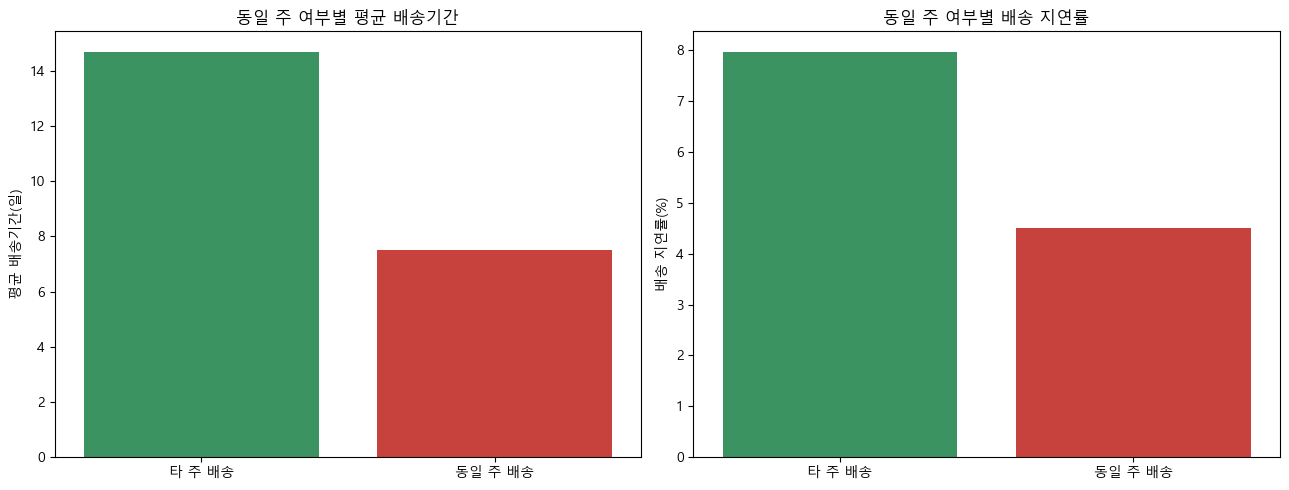

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=same_state_summary,
    x="same_state_label",
    y="avg_delivery_days",
    palette=["#2ca25f", "#de2d26"],
    ax=axes[0]
)

axes[0].set_title("동일 주 여부별 평균 배송기간")
axes[0].set_xlabel("")
axes[0].set_ylabel("평균 배송기간(일)")

sns.barplot(
    data=same_state_summary,
    x="same_state_label",
    y="delay_rate_pct",
    palette=["#2ca25f", "#de2d26"],
    ax=axes[1]
)

axes[1].set_title("동일 주 여부별 배송 지연률")
axes[1].set_xlabel("")
axes[1].set_ylabel("배송 지연률(%)")

plt.tight_layout()
plt.show()

## 해석 예시

Mann-Whitney U test의 p-value가 0.05보다 작고 동일 주 배송의 평균 배송기간이 짧다면, 고객과 가까운 위치에서 출고되는 것이 배송기간 단축에 유리하다고 해석할 수 있다.

카이제곱 검정의 p-value가 0.05보다 작고 동일 주 배송의 지연률이 낮다면, 지역 내 물류 거점 확보가 배송 지연 감소에도 기여할 수 있다는 근거가 된다.

# 최종 후보 산정: 사전재고 후보와 병목 허브 후보

## 목적

앞선 통계검정 결과를 바탕으로 두 가지 후보를 도출한다.

1. 주요 지역 창고에 사전 배치할 카테고리 후보
2. 추가 물류 허브가 필요한 병목 route 후보

이는 통계검정 결과를 실제 의사결정 기준으로 연결하기 위한 단계이다.

In [38]:
# 사전재고 후보 TOP 20
stock_candidates = region_cat_summary.sort_values(
    "stock_priority_score",
    ascending=False
).head(20)

display(stock_candidates[[
    "customer_region",
    "category",
    "order_count",
    "delay_rate_pct",
    "avg_delivery_days",
    "avg_review_score",
    "stock_priority_score"
]])

,customer_region,category,order_count,delay_rate_pct,avg_delivery_days,avg_review_score,stock_priority_score
38,북동부,health_beauty,1028,15.758755,19.575875,3.984436,0.823077
44,북동부,watches_gifts,704,12.357955,19.420455,4.000000,0.749231
42,북동부,telephony,604,13.741722,19.514901,3.859272,0.732308
41,북동부,sports_leisure,647,11.591963,18.769706,4.030139,0.730769
36,북동부,furniture_decor,476,14.495798,20.876050,3.815126,0.716923
2,남동부,bed_bath_table,6852,6.830123,11.243870,4.025832,0.710769
17,남부,bed_bath_table,1169,7.356715,14.813516,3.969204,0.704615
32,북동부,bed_bath_table,487,12.731006,20.638604,3.815195,0.693846
30,북동부,auto,411,16.058394,20.209246,3.817518,0.678462
33,북동부,computers_accessories,609,9.852217,18.395731,4.077176,0.663077


In [39]:
# 병목 route 후보 TOP 20
hub_candidates = route_summary.sort_values(
    "bottleneck_score",
    ascending=False
).head(20)

display(hub_candidates[[
    "order_count",
    "delay_rate_pct",
    "avg_delivery_days",
    "avg_delay_days",
    "avg_review_score",
    "bottleneck_score"
]])

,order_count,delay_rate_pct,avg_delivery_days,avg_delay_days,avg_review_score,bottleneck_score
delivery_route,,,,,,
SP -> RJ,7975,14.068966,15.827085,-10.793103,3.883490,0.880435
SP -> BA,2263,12.682280,19.323023,-10.798498,3.866107,0.880435
SP -> CE,948,13.818565,20.835443,-10.892405,3.965717,0.847826
SP -> MA,475,19.157895,21.553684,-9.309474,3.718947,0.826087
SP -> PA,663,11.613876,22.788839,-14.085973,3.868778,0.807971
SP -> ES,1430,12.097902,15.284615,-9.614685,4.044755,0.786232
PR -> RJ,940,11.914894,16.841489,-13.077660,3.890426,0.781884
SP -> PE,1105,9.773756,18.416290,-13.660633,4.039819,0.781159
SP -> SC,2271,9.599295,15.383531,-10.966535,4.029943,0.766667


# 종합 해석 예시

본 분석은 배송 지연을 줄이기 위한 두 가지 물류 전략을 검토하였다.

첫째, 수요가 많은 카테고리를 주요 지역 창고에 사전 배치하는 전략이다.  
카이제곱 검정 결과 고객 권역별 카테고리 수요 분포가 유의하게 다르다면, 권역별로 동일한 재고를 배치하는 것보다 지역 수요에 맞춘 카테고리별 사전재고 전략이 더 적절하다.

또한 카테고리별 배송 지연률과 배송기간에 유의미한 차이가 존재한다면, 단순히 판매량이 높은 카테고리가 아니라 수요가 많고 배송 지연률이 높은 카테고리를 우선적으로 사전 배치해야 한다.

둘째, 병목 route에 추가 물류 허브를 구축하는 전략이다.  
배송 route별 지연률 차이가 통계적으로 유의하다면, 특정 route에서 배송 병목이 집중되고 있음을 의미한다. 주문 수가 많고 지연률 및 평균 배송기간이 높은 route는 추가 허브 또는 중간 물류 거점 후보로 검토할 수 있다.

동일 주 배송이 타 주 배송보다 배송기간이 짧고 지연률이 낮다면, 고객 수요지 가까이에 물류 거점을 배치하는 전략의 타당성이 강화된다.

결론적으로, 물류 허브 및 창고 전략은 단순 주문량 기준이 아니라 다음 기준을 함께 고려해야 한다.

1. 고객 권역별 주문 수요
2. 권역별 주요 카테고리 수요
3. 카테고리별 배송 지연률
4. 권역-카테고리 조합별 지연률
5. route별 병목 정도
6. 동일 주 배송의 성과 개선 효과
7. 배송 지연이 리뷰점수에 미치는 영향

이를 통해 Olist의 물류 개선 전략은 “어디에 허브를 둘 것인가”뿐 아니라 “어떤 상품을 어느 지역에 미리 둘 것인가”까지 확장될 수 있다.

---

# 추가 검정 1. 판매자 권역별 배송 성과는 차이가 있는가?

## 왜 이 검정이 필요한가?

물류 허브 선정은 고객이 어디에 있는지만 보고 결정할 수 없다.

배송은 판매자 위치에서 출발하기 때문에, 판매자 권역별 출고 구조가 배송기간과 지연률에 어떤 영향을 주는지 확인해야 한다.

만약 특정 판매자 권역에서 출발하는 주문의 배송기간이 길거나 지연률이 높다면, 해당 권역은 출고 인프라가 부족하거나 장거리 배송 부담이 큰 지역일 수 있다.

따라서 판매자 권역별 배송 성과 검정은 다음 의사결정에 필요하다.

1. 기존 판매자 밀집 지역의 출고 효율성 평가
2. 특정 판매자 권역의 물류 병목 확인
3. 신규 허브를 고객 권역에 둘지, 판매자 권역 근처에 둘지 판단
4. 출고지-수요지 간 거리 불균형 문제 확인

## 분석 목적

판매자 권역별로 배송기간과 배송 지연률에 차이가 있는지 검정한다.

## 가설 1: 판매자 권역별 배송기간 차이

- H0: 판매자 권역별 배송기간 분포는 같다.
- H1: 판매자 권역별 배송기간 분포는 적어도 한 권역에서 다르다.

## 사용 검정

- ANOVA
- Kruskal-Wallis 검정

배송기간은 이상치가 존재할 수 있으므로 Kruskal-Wallis 검정을 우선적으로 해석한다.

## 가설 2: 판매자 권역별 배송 지연률 차이

- H0: 판매자 권역과 배송 지연 여부는 독립이다.
- H1: 판매자 권역과 배송 지연 여부는 독립이 아니다.

## 사용 검정

- 카이제곱 독립성 검정

In [43]:
seller_region_df = order_df.dropna(subset=[
    "seller_region",
    "delivery_days_clean",
    "is_delay"
]).copy()

seller_region_summary = seller_region_df.groupby("seller_region").agg(
    order_count=("order_id", "count"),
    avg_delivery_days=("delivery_days_clean", "mean"),
    median_delivery_days=("delivery_days_clean", "median"),
    delay_rate=("is_delay", "mean"),
    avg_review_score=("review_score_mean", "mean")
).sort_values("avg_delivery_days", ascending=False)

seller_region_summary["delay_rate_pct"] = seller_region_summary["delay_rate"] * 100

display(seller_region_summary)

,order_count,avg_delivery_days,median_delivery_days,delay_rate,avg_review_score,delay_rate_pct
seller_region,,,,,,
북부,24,20.000000,16.0,0.041667,3.833333,4.166667
북동부,1486,14.361373,12.0,0.081427,4.171602,8.142665
남부,12657,12.805009,11.0,0.048748,4.215809,4.874773
중서부,1412,12.361898,11.0,0.043909,4.208215,4.390935
남동부,78864,11.950117,10.0,0.070438,4.142982,7.043772


In [44]:
# 판매자 권역별 배송기간 차이 검정

groups = [
    group["delivery_days_clean"].values
    for _, group in seller_region_df.groupby("seller_region")
]

anova_seller_region = stats.f_oneway(*groups)
kruskal_seller_region = stats.kruskal(*groups)

print("ANOVA:", anova_seller_region)
print("Kruskal-Wallis:", kruskal_seller_region)

ANOVA: F_onewayResult(statistic=np.float64(47.95531679225536), pvalue=np.float64(2.3674791732124323e-40))
Kruskal-Wallis: KruskalResult(statistic=np.float64(569.524662199443), pvalue=np.float64(6.09952378897537e-122))


In [45]:
# 판매자 권역별 지연률 차이 검정

seller_region_late_table = pd.crosstab(
    seller_region_df["seller_region"],
    seller_region_df["is_delay"]
)

display(seller_region_late_table)

chi2, p, dof, expected = stats.chi2_contingency(seller_region_late_table)

n = seller_region_late_table.to_numpy().sum()
r, c = seller_region_late_table.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)
print("Cramer's V:", cramers_v)

is_delay,False,True
seller_region,,
남동부,73309,5555
남부,12040,617
북동부,1365,121
북부,23,1
중서부,1350,62


Chi-square statistic: 99.05379903479728
p-value: 1.5640962805143047e-20
degrees of freedom: 4
Cramer's V: 0.03238550558117025


C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\45087993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\45087993.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


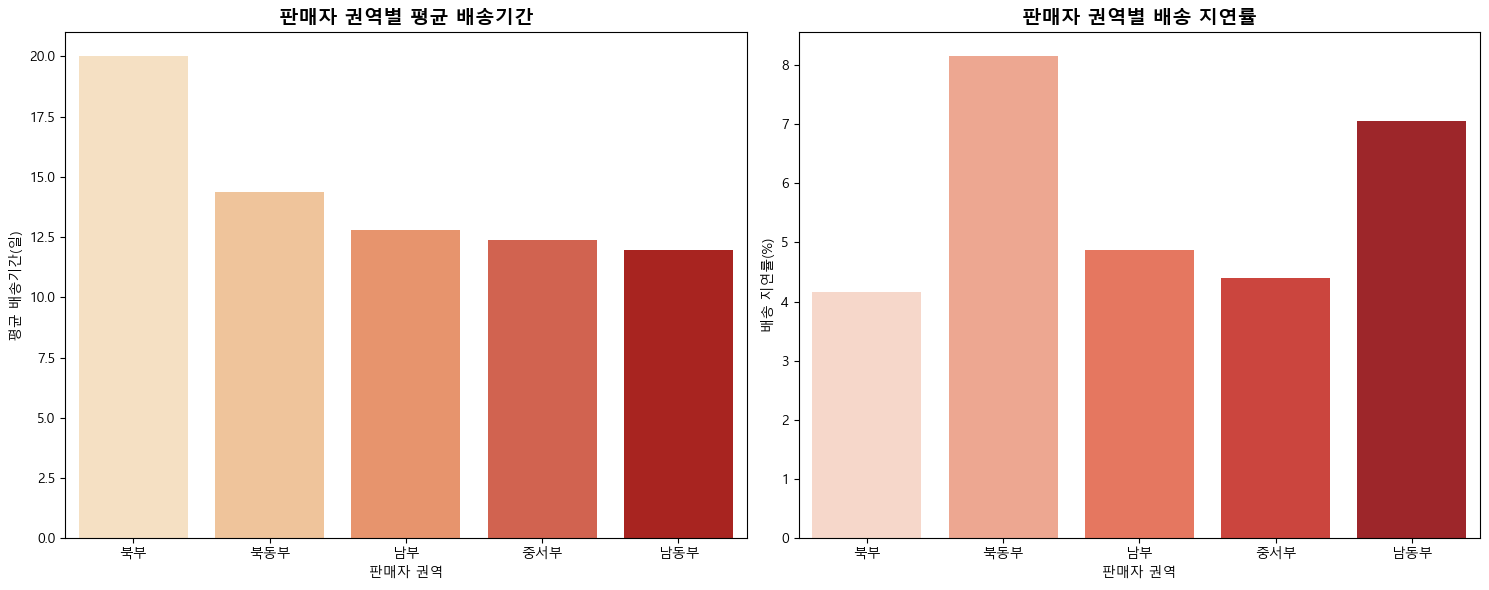

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    data=seller_region_summary.reset_index(),
    x="seller_region",
    y="avg_delivery_days",
    palette="OrRd",
    ax=axes[0]
)

axes[0].set_title("판매자 권역별 평균 배송기간", fontsize=14, weight="bold")
axes[0].set_xlabel("판매자 권역")
axes[0].set_ylabel("평균 배송기간(일)")

sns.barplot(
    data=seller_region_summary.reset_index(),
    x="seller_region",
    y="delay_rate_pct",
    palette="Reds",
    ax=axes[1]
)

axes[1].set_title("판매자 권역별 배송 지연률", fontsize=14, weight="bold")
axes[1].set_xlabel("판매자 권역")
axes[1].set_ylabel("배송 지연률(%)")

plt.tight_layout()
plt.show()

## 결과 해석 예시

Kruskal-Wallis 검정의 p-value가 0.05보다 작다면 판매자 권역별 배송기간에는 통계적으로 유의미한 차이가 있다고 판단한다.

또한 카이제곱 검정의 p-value가 0.05보다 작다면 판매자 권역과 배송 지연 여부는 독립이 아니며, 특정 판매자 권역에서 지연이 더 많이 발생한다고 볼 수 있다.

만약 특정 판매자 권역의 평균 배송기간과 지연률이 높다면, 해당 권역은 출고 병목이 발생하는 지역일 수 있다.

허브 선정 관점에서는 고객 수요 지역뿐 아니라 판매자 출고 지역의 배송 성과도 함께 고려해야 한다.

# 추가 검정 2. 고수요 route는 저수요 route보다 배송 성과가 나쁜가?

## 왜 이 검정이 필요한가?

물류 병목은 단순히 특정 route의 지연률이 높다는 사실만으로 판단하기 어렵다.

주문 수가 적은 route에서 지연률이 높게 나타나는 것은 우연일 수 있다.  
반면 주문 수가 많은 route에서 지연률과 배송기간이 높게 나타난다면, 이는 실제 물류 병목일 가능성이 크다.

따라서 route를 주문량 기준으로 고수요 route와 저수요 route로 나누고, 두 집단의 배송 성과가 다른지 검정할 필요가 있다.

이 검정은 다음 의사결정에 필요하다.

1. 병목 route가 단순한 이상치인지, 구조적 문제인지 확인
2. 주문량이 많은 핵심 route의 물류 부담 평가
3. 추가 허브 또는 중간 물류 거점이 필요한 route 선정
4. route별 개선 우선순위 도출

## 분석 목적

고수요 route와 저수요 route의 배송기간 및 지연률 차이를 검정한다.

## 고수요 route 정의

전체 route 중 주문 수 상위 25%를 고수요 route로 정의한다.

## 가설 1: 고수요 route와 저수요 route의 배송기간 차이

- H0: 고수요 route와 저수요 route의 배송기간 분포는 같다.
- H1: 고수요 route와 저수요 route의 배송기간 분포는 다르다.

## 사용 검정

- Mann-Whitney U test

## 가설 2: 고수요 route와 저수요 route의 지연률 차이

- H0: route 수요군과 배송 지연 여부는 독립이다.
- H1: route 수요군과 배송 지연 여부는 독립이 아니다.

## 사용 검정

- 카이제곱 독립성 검정

In [47]:
route_order_counts = order_df["delivery_route"].value_counts()

route_threshold = route_order_counts.quantile(0.75)

high_demand_routes = route_order_counts[
    route_order_counts >= route_threshold
].index

order_df["route_demand_group"] = np.where(
    order_df["delivery_route"].isin(high_demand_routes),
    "고수요 route",
    "저수요 route"
)

route_demand_summary = order_df.groupby("route_demand_group").agg(
    order_count=("order_id", "count"),
    route_count=("delivery_route", "nunique"),
    avg_delivery_days=("delivery_days_clean", "mean"),
    median_delivery_days=("delivery_days_clean", "median"),
    delay_rate=("is_delay", "mean"),
    avg_review_score=("review_score_mean", "mean")
)

route_demand_summary["delay_rate_pct"] = route_demand_summary["delay_rate"] * 100

display(route_demand_summary)

,order_count,route_count,avg_delivery_days,median_delivery_days,delay_rate,avg_review_score,delay_rate_pct
route_demand_group,,,,,,,
고수요 route,91573,103,11.941784,10.0,0.066799,4.153966,6.679917
저수요 route,2870,304,17.504530,15.0,0.083275,4.158014,8.327526


In [48]:
# 고수요 route vs 저수요 route 배송기간 차이 검정

high_route_delivery = order_df.loc[
    order_df["route_demand_group"] == "고수요 route",
    "delivery_days_clean"
].dropna()

low_route_delivery = order_df.loc[
    order_df["route_demand_group"] == "저수요 route",
    "delivery_days_clean"
].dropna()

mw_route_demand = stats.mannwhitneyu(
    high_route_delivery,
    low_route_delivery,
    alternative="two-sided"
)

print("고수요 route 평균 배송기간:", high_route_delivery.mean())
print("저수요 route 평균 배송기간:", low_route_delivery.mean())
print("Mann-Whitney U:", mw_route_demand)

고수요 route 평균 배송기간: 11.941784150349994
저수요 route 평균 배송기간: 17.50452961672474
Mann-Whitney U: MannwhitneyuResult(statistic=np.float64(78092408.5), pvalue=np.float64(1.4100958474828313e-301))


In [49]:
# 고수요 route vs 저수요 route 지연률 차이 검정

route_demand_late_table = pd.crosstab(
    order_df["route_demand_group"],
    order_df["is_delay"]
)

display(route_demand_late_table)

chi2, p, dof, expected = stats.chi2_contingency(route_demand_late_table)

n = route_demand_late_table.to_numpy().sum()
phi = np.sqrt(chi2 / n)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)
print("Phi coefficient:", phi)

is_delay,False,True
route_demand_group,,
고수요 route,85456,6117
저수요 route,2631,239


Chi-square statistic: 11.773559836537908
p-value: 0.000600779751092838
degrees of freedom: 1
Phi coefficient: 0.011165264368172785


C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\2307554908.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\2307554908.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


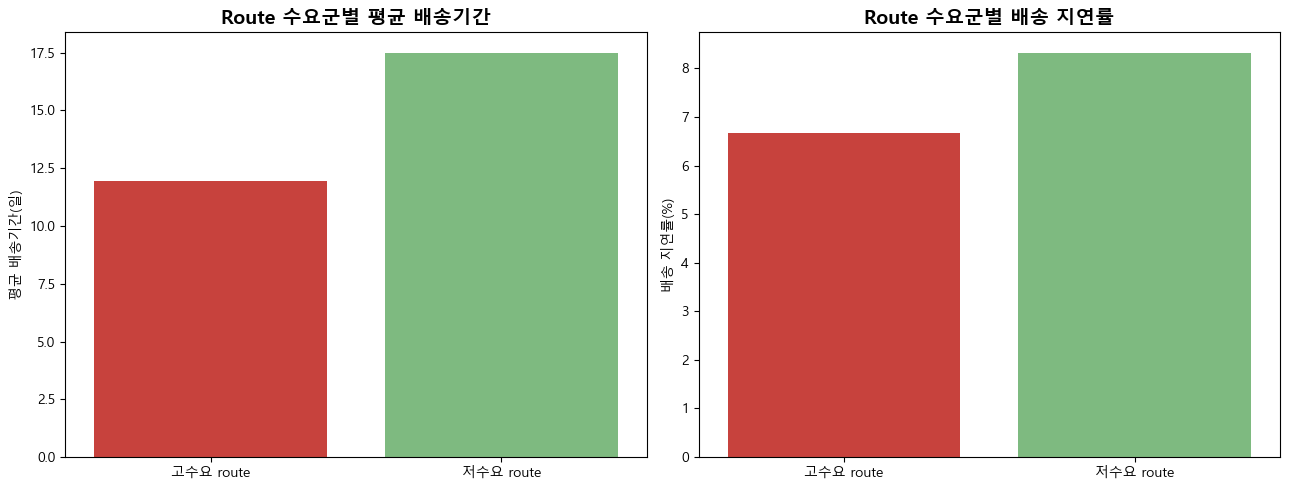

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_df = route_demand_summary.reset_index()

sns.barplot(
    data=plot_df,
    x="route_demand_group",
    y="avg_delivery_days",
    palette=["#de2d26", "#74c476"],
    ax=axes[0]
)

axes[0].set_title("Route 수요군별 평균 배송기간", fontsize=14, weight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("평균 배송기간(일)")

sns.barplot(
    data=plot_df,
    x="route_demand_group",
    y="delay_rate_pct",
    palette=["#de2d26", "#74c476"],
    ax=axes[1]
)

axes[1].set_title("Route 수요군별 배송 지연률", fontsize=14, weight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("배송 지연률(%)")

plt.tight_layout()
plt.show()

## 결과 해석 예시

Mann-Whitney U test의 p-value가 0.05보다 작다면 고수요 route와 저수요 route의 배송기간 분포에는 통계적으로 유의미한 차이가 있다고 해석한다.

카이제곱 검정의 p-value가 0.05보다 작다면 route 수요군과 배송 지연 여부는 독립이 아니며, 수요 규모에 따라 지연률이 달라진다고 볼 수 있다.

고수요 route에서 평균 배송기간과 지연률이 높다면, 해당 route는 물류량이 집중되어 병목이 발생하는 핵심 경로로 볼 수 있다.

이 경우 고수요 route를 완화할 수 있는 중간 허브나 추가 물류 거점을 검토할 수 있다.

# 추가 검정 3. 사전재고 후보군은 비후보군보다 배송 문제가 큰가?

## 왜 이 검정이 필요한가?

수요가 많은 카테고리의 상품을 주요 지역 창고에 미리 저장하는 전략을 제안하려면, 먼저 사전재고 후보군이 실제로 배송 문제가 큰 집단인지 검증해야 한다.

단순히 주문 수가 많다는 이유만으로 사전재고를 운영하면 창고 비용이 증가할 수 있다.

따라서 사전재고 후보군은 다음 조건을 만족해야 한다.

1. 주문 수요가 많다.
2. 배송 지연률이 높다.
3. 평균 배송기간이 길다.
4. 고객 만족도에 부정적 영향을 줄 가능성이 있다.

이 검정은 우리가 선정한 사전재고 후보군이 비후보군보다 실제로 배송 성과가 나쁜지 확인하기 위해 필요하다.

## 분석 목적

권역-카테고리 조합 중 `stock_priority_score`가 높은 후보군과 비후보군의 배송기간 및 지연률 차이를 검정한다.

## 후보군 정의

`stock_priority_score` 상위 25% 권역-카테고리 조합을 사전재고 후보군으로 정의한다.

## 가설 1: 후보군과 비후보군의 배송기간 차이

- H0: 사전재고 후보군과 비후보군의 배송기간 분포는 같다.
- H1: 사전재고 후보군과 비후보군의 배송기간 분포는 다르다.

## 사용 검정

- Mann-Whitney U test

## 가설 2: 후보군과 비후보군의 지연률 차이

- H0: 사전재고 후보군 여부와 배송 지연 여부는 독립이다.
- H1: 사전재고 후보군 여부와 배송 지연 여부는 독립이 아니다.

## 사용 검정

- 카이제곱 독립성 검정

In [51]:
# region_cat_summary가 이미 생성되어 있어야 함
# 없다면 이전 권역-카테고리 분석 셀을 먼저 실행

stock_threshold = region_cat_summary["stock_priority_score"].quantile(0.75)

region_cat_summary["is_stock_candidate_combo"] = (
    region_cat_summary["stock_priority_score"] >= stock_threshold
)

candidate_combos = region_cat_summary.loc[
    region_cat_summary["is_stock_candidate_combo"],
    ["customer_region", "category"]
].copy()

candidate_combos["is_stock_candidate"] = True

stock_test_df = order_category_df.merge(
    candidate_combos,
    on=["customer_region", "category"],
    how="left"
)

stock_test_df["is_stock_candidate"] = (
    stock_test_df["is_stock_candidate"]
    .fillna(False)
    .astype(bool)
)

stock_candidate_summary = stock_test_df.groupby("is_stock_candidate").agg(
    order_count=("order_id", "nunique"),
    combo_count=("category", "count"),
    avg_delivery_days=("delivery_days_clean", "mean"),
    median_delivery_days=("delivery_days_clean", "median"),
    delay_rate=("is_delay", "mean"),
    avg_review_score=("review_score_mean", "mean")
)

stock_candidate_summary["delay_rate_pct"] = stock_candidate_summary["delay_rate"] * 100

display(stock_candidate_summary)

,order_count,combo_count,avg_delivery_days,median_delivery_days,delay_rate,avg_review_score,delay_rate_pct
is_stock_candidate,,,,,,,
False,60213,60500,11.971868,10.0,0.061934,4.184028,6.193388
True,34590,34705,12.292004,10.0,0.075666,4.077655,7.566633


In [52]:
# 사전재고 후보군 vs 비후보군 배송기간 차이 검정

candidate_delivery = stock_test_df.loc[
    stock_test_df["is_stock_candidate"] == True,
    "delivery_days_clean"
].dropna()

non_candidate_delivery = stock_test_df.loc[
    stock_test_df["is_stock_candidate"] == False,
    "delivery_days_clean"
].dropna()

mw_stock = stats.mannwhitneyu(
    candidate_delivery,
    non_candidate_delivery,
    alternative="two-sided"
)

print("사전재고 후보군 평균 배송기간:", candidate_delivery.mean())
print("비후보군 평균 배송기간:", non_candidate_delivery.mean())
print("Mann-Whitney U:", mw_stock)

사전재고 후보군 평균 배송기간: 12.292004034000865
비후보군 평균 배송기간: 11.971867768595041
Mann-Whitney U: MannwhitneyuResult(statistic=np.float64(1067633760.0), pvalue=np.float64(1.2497811868011405e-05))


In [53]:
# 사전재고 후보군 vs 비후보군 지연률 차이 검정

stock_late_table = pd.crosstab(
    stock_test_df["is_stock_candidate"],
    stock_test_df["is_delay"]
)

display(stock_late_table)

chi2, p, dof, expected = stats.chi2_contingency(stock_late_table)

n = stock_late_table.to_numpy().sum()
phi = np.sqrt(chi2 / n)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)
print("Phi coefficient:", phi)

is_delay,False,True
is_stock_candidate,,
False,56753,3747
True,32079,2626


Chi-square statistic: 66.36734606158464
p-value: 3.7425091171973807e-16
degrees of freedom: 1
Phi coefficient: 0.026402639558947272


C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\616321615.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_9492\616321615.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


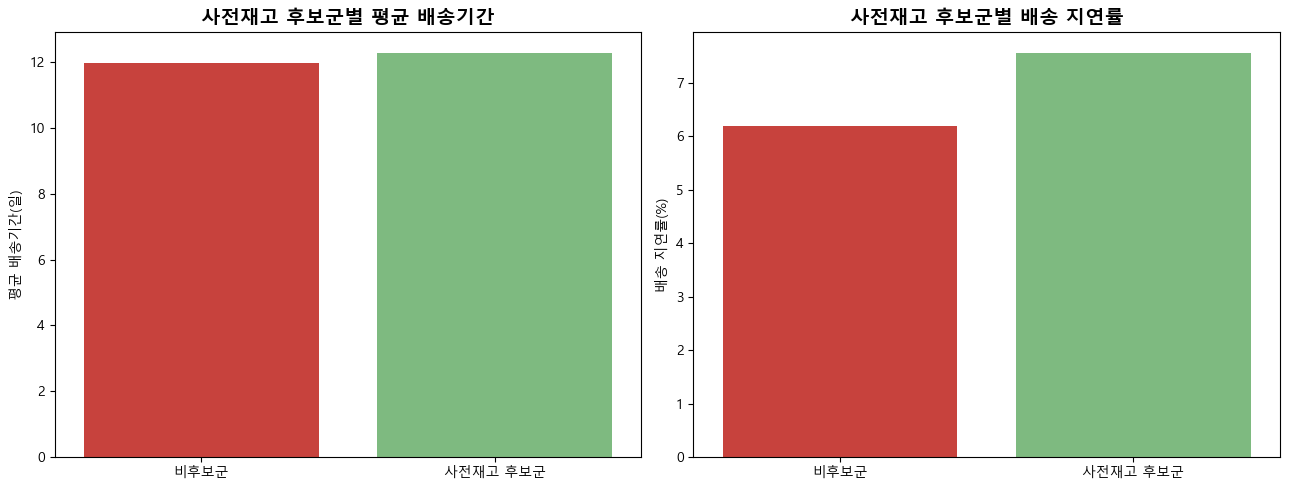

In [54]:
plot_df = stock_candidate_summary.reset_index()
plot_df["candidate_label"] = plot_df["is_stock_candidate"].map({
    True: "사전재고 후보군",
    False: "비후보군"
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=plot_df,
    x="candidate_label",
    y="avg_delivery_days",
    palette=["#de2d26", "#74c476"],
    ax=axes[0]
)

axes[0].set_title("사전재고 후보군별 평균 배송기간", fontsize=14, weight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("평균 배송기간(일)")

sns.barplot(
    data=plot_df,
    x="candidate_label",
    y="delay_rate_pct",
    palette=["#de2d26", "#74c476"],
    ax=axes[1]
)

axes[1].set_title("사전재고 후보군별 배송 지연률", fontsize=14, weight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("배송 지연률(%)")

plt.tight_layout()
plt.show()

## 결과 해석 예시

Mann-Whitney U test의 p-value가 0.05보다 작다면 사전재고 후보군과 비후보군의 배송기간 분포에는 통계적으로 유의미한 차이가 있다고 판단한다.

카이제곱 검정의 p-value가 0.05보다 작다면 사전재고 후보군 여부와 배송 지연 여부는 독립이 아니며, 후보군에서 지연이 더 자주 발생한다고 해석할 수 있다.

만약 사전재고 후보군의 평균 배송기간과 지연률이 비후보군보다 높다면, 해당 후보군은 실제로 배송 문제가 큰 권역-카테고리 조합이라고 볼 수 있다.

따라서 주요 지역 창고에 해당 카테고리를 사전 배치하는 전략은 단순 아이디어가 아니라, 데이터 기반 물류 개선 전략으로 제안할 수 있다.

# 추가 검정 종합 해석

이번 추가 검정은 기존의 권역별, route별 배송 성과 분석을 확장하여 물류 전략의 실행 가능성을 검증하기 위한 것이다.

첫째, 판매자 권역별 배송 성과 차이를 검정함으로써 배송 문제를 고객 지역뿐 아니라 출고 지역 관점에서도 확인하였다.  
특정 판매자 권역에서 배송기간과 지연률이 높다면 해당 권역은 출고 인프라 개선 또는 허브 연결성 강화가 필요한 지역으로 볼 수 있다.

둘째, route를 수요 규모에 따라 구분하여 고수요 route와 저수요 route의 배송 성과를 비교하였다.  
고수요 route에서 배송기간과 지연률이 높다면 이는 단순한 우연이 아니라 물량 집중으로 인한 구조적 병목일 가능성이 있다.  
따라서 해당 route를 완화할 수 있는 중간 허브 또는 추가 물류 거점 구축이 필요하다.

셋째, 사전재고 후보군과 비후보군의 배송 성과를 비교하였다.  
사전재고 후보군의 배송기간과 지연률이 유의하게 높다면, 권역별 창고에 고수요·고지연 카테고리를 미리 배치하는 전략의 타당성이 강화된다.

결론적으로 물류 개선 전략은 다음 두 방향으로 제안할 수 있다.

1. 고수요·고지연 route에는 추가 물류 허브 또는 중간 거점을 구축한다.
2. 고수요·고지연 권역-카테고리 조합은 주요 지역 창고에 사전재고로 배치한다.

이러한 접근은 단순히 배송이 느린 지역을 찾는 것을 넘어, 어떤 route를 개선하고 어떤 상품을 어디에 미리 보관해야 하는지까지 연결되는 실무적 물류 전략이다.